In [45]:
import pandas as pd
import gdown
# from pivottablejs import pivot_ui
# from openai import OpenAI
# from dotenv import dotenv_values
# import re
# import json
# import glob
# import numpy as np
# import io
# import pyarrow as pa

# pa.PyExtensionType.set_auto_load(True)

In [46]:
dict_plikow = {
    'towar': 'https://drive.google.com/file/d/1BnYuwCY4A7fzb5Vg36r6vpCbRhM_acDZ/view?usp=drive_link',
    'pozdok': 'https://drive.google.com/file/d/1q9x3lCAb9u0BPqbEzGJLhdkESDon33Sl/view?usp=drive_link',
    'dok':'https://drive.google.com/file/d/1ONZ1yvmTAsGq1P9FieuZvyRINUNHj1dk/view?usp=drive_link',
    'asort': 'https://drive.google.com/file/d/15vZYClznfSQDGO_qS0gPJ3J9Vo5ZKzsS/view?usp=sharing'
}



In [47]:
for key, url in dict_plikow.items():
    gdown.download(url, f"dane/{key}.parquet", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1BnYuwCY4A7fzb5Vg36r6vpCbRhM_acDZ
To: /Users/mixer/python/analiza_sprzedazy_w_sklepie/dane/towar.parquet
100%|██████████| 3.27M/3.27M [00:00<00:00, 7.06MB/s]
Downloading...
From: https://drive.google.com/uc?id=1q9x3lCAb9u0BPqbEzGJLhdkESDon33Sl
To: /Users/mixer/python/analiza_sprzedazy_w_sklepie/dane/pozdok.parquet
100%|██████████| 71.2M/71.2M [00:11<00:00, 6.24MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ONZ1yvmTAsGq1P9FieuZvyRINUNHj1dk
To: /Users/mixer/python/analiza_sprzedazy_w_sklepie/dane/dok.parquet
100%|██████████| 42.0M/42.0M [00:05<00:00, 7.49MB/s]
Downloading...
From: https://drive.google.com/uc?id=15vZYClznfSQDGO_qS0gPJ3J9Vo5ZKzsS
To: /Users/mixer/python/analiza_sprzedazy_w_sklepie/dane/asort.parquet
100%|██████████| 17.4k/17.4k [00:00<00:00, 14.7MB/s]


#  DOK

In [48]:
pozdok = pd.read_parquet('dane/pozdok.parquet', engine='pyarrow')


In [49]:
pozdok.columns

Index(['DokId', 'Kolejnosc', 'NrPozycji', 'TowId', 'TypPoz', 'IloscPlus',
       'IloscMinus', 'PoziomCen', 'Metoda', 'CenaDomyslna', 'CenaPrzedRab',
       'RabatProc', 'CenaPoRab', 'Wartosc', 'CenaDet', 'CenaMag', 'Stawka',
       'TypTowaru', 'IleWZgrzewce', 'StawkaDod', 'Netto', 'Podatek',
       'SledzPartii', 'UUID'],
      dtype='str')

In [50]:
pozdok = pozdok.drop(columns=['IleWZgrzewce','StawkaDod','Netto','Podatek','SledzPartii', 'UUID','Metoda','PoziomCen',
                              'Kolejnosc','NrPozycji','TypPoz'
                              
                              ]).copy()

In [51]:
pozdok.columns

Index(['DokId', 'TowId', 'IloscPlus', 'IloscMinus', 'CenaDomyslna',
       'CenaPrzedRab', 'RabatProc', 'CenaPoRab', 'Wartosc', 'CenaDet',
       'CenaMag', 'Stawka', 'TypTowaru'],
      dtype='str')

In [52]:
# asort = pd.read_csv('dane_all_product/ASORT.csv', sep=',', low_memory=False, on_bad_lines='skip', index_col=False, encoding='latin-1')
# asort = asort.to_parquet('dane_all_product/asort.parquet', index=False)
# asort = pd.read_parquet('dane_all_product/ASORT.parquet')
asort = pd.read_parquet('dane/asort.parquet')

In [53]:
asort=asort.drop(columns=['OpcjaMarzy',
'HurtRabat',
'OpcjaRabatu',
'NocNarzut',
'OpcjaNarzutu',
'CentrAsId',
'UkrytyNaPanelach',
'UkrytyNaBonowniku',
'BezAutoEtykiet',
'Param1',
'Autoryzacja'
]).copy()

In [54]:
asort.sample(10)

,AsId,Nazwa,Marza
216,74,FRYTKI,0.0
212,70,WĘDLINY PACZKOWANE,0.0
198,348,MIĘSO PACZKOWANE,0.0
77,162,KRAKERSY /przekąski,0.0
28,40,MAJONEZY /dodatki spożywcze,0.0
276,224,GUMY DO ŻUCIA,0.0
165,312,WIELKANOCNE,0.0
90,176,ARTYKUŁY SEZONOWE I DEKORACJE /przemysło,0.0
145,280,10 PAPIEROWE,0.0
24,36,DANIA KUB 5MIN /dodatki spożywcze,0.0


## Towar

In [55]:
towar = pd.read_parquet('dane/towar.parquet')

In [56]:
towar.columns

Index(['TowId', 'AsId', 'JMId', 'KatId', 'Producent', 'ArtId', 'Nazwa',
       'Skrot', 'Kod', 'TypTowaru', 'Indeks1', 'Indeks2', 'Opis1', 'Opis2',
       'Opis3', 'Opis4', 'TermWazn', 'Marza', 'HurtRabat', 'NocNarzut',
       'OpcjaMarzy', 'OpcjaRabatu', 'OpcjaNarzutu', 'CenaEw', 'CenaDet',
       'CenaHurt', 'CenaNoc', 'CenaDod', 'CenaOtwarta', 'PoziomCen', 'PrefPLU',
       'Stawka', 'IleWZgrzewce', 'IleWCalosci', 'KodZgrzewki', 'Aktywny',
       'Waga', 'Szerokosc', 'Wysokosc', 'Glebokosc', 'CKU', 'BlokDostawcow',
       'BlokCenyZak', 'BlokCenSp', 'BlokZmian', 'Rezerwa1', 'Rezerwa2',
       'CentrTowId', 'Zmiana', 'Akcyzowy', 'SledzPartii', 'MaxCenaZak',
       'PrzeliczJM', 'NrDrukarki', 'Cena5', 'Cena6', 'ProgPromocji',
       'ZmianaIstotna', 'ZmianaTylkoCen', 'Przeznaczenie', 'ObslugaPartii',
       'UkrycNaKasie', 'KodCN', 'MinCenaSp', 'SubsysKoduGlownego', 'StatusZam',
       'KodGlownyCentralny', 'NowoscOd', 'NowoscPrzez',
       'WysylacNaSklepInternetowy', 'GrupaGTU', 'Kr

In [57]:
towar=towar.drop(columns=['JMId',
'KatId',
'Producent',
'ArtId',
'Skrot',
'TypTowaru',
'Indeks1',
'Indeks2',
'Opis1',
'Opis2',
'Opis3',
'Opis4',
'TermWazn',
'HurtRabat',
'NocNarzut',
'OpcjaMarzy',
'OpcjaRabatu',
'OpcjaNarzutu',
'CenaNoc',
'CenaDod',
'CenaOtwarta',
'PoziomCen',
'PrefPLU',
'IleWZgrzewce',
'IleWCalosci',
'Opis4',
'TermWazn',
'HurtRabat',
'NocNarzut',
'OpcjaMarzy',
'OpcjaRabatu',
'OpcjaNarzutu',
'CenaNoc',
'CenaDod',
'CenaOtwarta',
'PoziomCen',
'PrefPLU',
'IleWZgrzewce',
'IleWCalosci',
'KodZgrzewki',
'Aktywny',
       'Waga', 'Szerokosc', 'Wysokosc', 'Glebokosc', 'CKU', 'BlokDostawcow',
       'BlokCenyZak', 'BlokCenSp', 'BlokZmian', 'Rezerwa1', 'Rezerwa2',
       'CentrTowId', 'Zmiana', 'Akcyzowy', 'SledzPartii', 'MaxCenaZak',
       'PrzeliczJM', 'NrDrukarki', 'Cena5', 'Cena6', 'ProgPromocji',
       'ZmianaIstotna', 'ZmianaTylkoCen', 'Przeznaczenie', 'ObslugaPartii',
       'UkrycNaKasie', 'KodCN', 'MinCenaSp', 'SubsysKoduGlownego', 'StatusZam',
       'KodGlownyCentralny', 'NowoscOd', 'NowoscPrzez',
       'WysylacNaSklepInternetowy', 'GrupaGTU', 'KrajIdPochodzenia', 'Zywnosc',
       'KodSklepu','CenaHurt','CenaEw','Stawka'
]).copy()




In [58]:

dok = pd.read_parquet('dane/dok.parquet')

In [59]:
dok = dok.drop(columns=['UzId',
'MagId',
'KolejnyWDniu',
'DataDod',
'DataPom',
'Aktywny',
'Opcja1',
'Opcja2',
'Opcja3',
'Opcja4',
'CenyZakBrutto',
'Opcja3',
'Opcja4',
'CenyZakBrutto',
'Aktywny',
'Opcja1',
'Opcja2',
'Opcja3',
'Opcja4',
'CenyZakBrutto',
'Kwota1', 'Kwota2', 'Kwota3', 'Kwota4',
       'Kwota5', 'Kwota6', 'Kwota7', 'Kwota8', 'Kwota9', 'Kwota10', 'Param1',
       'Param2', 'Param3', 'Param4', 'EksportFK', 'Zmiana', 'NrKolejny',
       'NrKolejnyMag', 'Param5', 'Param6', 'Kwota11', 'Kwota12', 'WalId',
       'Kurs', 'CentrDokId', 'Opcja5', 'Opcja6', 'Opcja7', 'Opcja8',
       'ZmianaPkt', 'ZaplaconoPodatek', 'ZaplaconoWKasie', 'WalIdPlatnosci',
       'DataWystKSeF', 'DaneWystId', 'Opcja9', 'Opcja10', 'Opcja11', 'Opcja12',
       'Kwota13', 'Kwota14', 'Kwota15', 'Kwota16', 'UUID','CenySpBrutto','FormaPlat','TerminPlat','NettoUslugi','PodatekUslugi','PodatekUslugi',
       'PodatekDetUslugi', 'NettoMag', 'PodatekMag',
       'NettoMagUslugi', 'PodatekMagUslugi', 'Razem', 'DoZaplaty',
       'Zaplacono','PoziomCen','NettoDet','PodatekDet','NettoDetUslugi'

]).copy()


In [60]:
dok = dok.drop_duplicates()

In [61]:
dok.sample(10)

,DokId,Data,NrDok,TypDok,RabatProc,Netto,Podatek
624027,1254976,2023-04-04,DF/PAR/230404/1318/1,21,0.0,37.69,0.44
440245,2208444,2025-12-27,DF/PAR/251227/14417/2,21,0.0,16.67,3.83
765999,1254987,2023-04-04,DF/PAR/230404/1251/2,21,0.0,9.35,2.15
533884,1888378,2025-01-07,ZMKAS/25/14/2,106,0.0,0.00,0.00
741980,2145237,2025-10-13,DF/PAR/251013/4008/1,21,0.0,15.81,1.49
280449,1602128,2024-02-27,DF/PAR/240227/9273/2,21,0.0,4.70,1.08
715262,2092539,2025-08-11,DF/PAR/250811/3558/1,21,0.0,25.46,4.78
234719,1926172,2025-02-20,DF/PAR/250220/7579/1,21,0.0,3.80,0.19
943122,1396869,2023-09-16,DF/PAR/230916/5680/1,21,0.0,22.17,0.00
490199,1424226,2023-10-18,D20231018/50189/CDPRS/23/201,81,0.0,145.55,11.64


In [62]:
dok['Data'] = pd.to_datetime(dok['Data'], errors='coerce').copy()


Przesuwanie rozdzielonych kolumn

## Usuwam te rekordy które w NrDok maja "NaN"

In [63]:
dok = dok[dok['NrDok'].notna()]

#  POZDOK

In [64]:
pozdok = pozdok.drop_duplicates()

## Łacze dok oraz pozdok 

In [65]:
pozdok_dok = pd.merge(pozdok, dok, on="DokId", how="left")

In [66]:
pozdok_dok = pozdok_dok.drop_duplicates()

In [67]:
pozdok_dok

,DokId,TowId,IloscPlus,IloscMinus,CenaDomyslna,CenaPrzedRab,RabatProc_x,CenaPoRab,Wartosc,CenaDet,CenaMag,Stawka,TypTowaru,Data,NrDok,TypDok,RabatProc_y,Netto,Podatek
0,41775,19623,1.000,0.0,745.6504,917.1500,0.0,917.1500,917.1500,745.6504,0.0000,2300,0,2018-09-14,1/09/L,33.0,0.0000,917.15,210.94
1,131173,23638,1.000,0.0,0.0000,112.5000,0.0,112.5000,112.5000,0.0000,0.0000,2300,2,2019-01-07,FV/19/4,33.0,0.0000,112.50,25.88
2,142162,23638,1.000,0.0,0.0000,75.0000,0.0,75.0000,75.0000,0.0000,0.0000,2300,2,2019-01-21,FV/19/7,33.0,0.0000,75.00,17.25
3,159723,23638,1.000,0.0,0.0000,7956.8100,0.0,7956.8100,7956.8100,0.0000,0.0000,2300,2,2019-02-11,FV/19/9,33.0,0.0000,7956.81,1830.07
4,162945,25390,1.000,0.0,100.0407,100.0000,0.0,100.0000,100.0000,100.0407,100.0000,2300,0,2019-02-22,FV/19/10,33.0,0.0000,100.00,23.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3812576,2237660,81803,1.000,0.0,5.2764,5.2764,0.0,5.2764,5.2764,5.2764,4.1333,2300,0,2026-01-31,DF/PAR/260131/12424/2,21.0,0.0447,87.71,8.52
3812577,2237660,81638,1.000,0.0,0.5000,0.5000,0.0,0.5000,0.5000,0.5000,0.5000,-1,6,2026-01-31,DF/PAR/260131/12424/2,21.0,0.0447,87.71,8.52
3812578,2237660,52905,1.000,0.0,2.4309,2.4309,0.0,2.4309,2.4309,2.4309,1.8200,2300,0,2026-01-31,DF/PAR/260131/12424/2,21.0,0.0447,87.71,8.52
3812579,2237660,80379,1.000,0.0,15.4390,15.4390,0.0,15.4390,15.4390,15.4390,14.8530,2300,0,2026-01-31,DF/PAR/260131/12424/2,21.0,0.0447,87.71,8.52


In [68]:
pozdok_dok[['RabatProc_x', 'RabatProc_y']].value_counts(dropna=False)

RabatProc_x  RabatProc_y
0.0000       0.0000         3705427
             NaN              15662
0.2400       0.0000            2248
0.2394       0.0000            1054
0.2405       0.0000             892
                             ...   
0.2391       0.2386               1
0.2386       0.2371               1
0.2407       0.2394               1
0.0000       0.3740               1
0.2407       0.2378               1
Name: count, Length: 2881, dtype: int64

In [69]:
pozdok_dok=pozdok_dok.drop(columns=['RabatProc_y']).copy()

In [70]:
pozdok_dok=pozdok_dok.rename(columns={'RabatProc_x': 'RabatProc'}).copy()

In [71]:
asort = asort.rename(columns={'Nazwa': 'Nazwa_asort'})

In [72]:
towar = towar.rename(columns={'Nazwa': 'Nazwa_towar'})

In [73]:
towar = towar.drop_duplicates()

In [74]:
towar['Kod'] = towar['Kod'].fillna(0)
towar['Kod']=towar['Kod'].astype('int')


## Łacze dataframes  "towar" oraz "asort" powstaje "towar_asort"

In [75]:
towar_asort = pd.merge(towar, asort, on="AsId", how="left")

In [76]:
towar_asort.sample(3)

,TowId,AsId,Nazwa_towar,Kod,Marza_x,CenaDet,Nazwa_asort,Marza_y
18396,12379,43,PIEPRZ ZIAR APPETITA CZARNY 18G COLIAN,5902795003011,0.25,1.5366,PRZYPRAWY,0.0
21555,8380,101,SYROP OWOCOWA SPIŻARNIA MALINA Z MELISĄ 420ML ...,5900956100609,0.20,6.4722,SYROPY I SOKI ZAGĘSZCZONE,0.0
39755,53194,132,TELE ŚWIAT,9771234267200,0.00,2.7685,PRASA,0.0


## Łacze dataframes  "pozdok_dok" oraz "towar_asort" powstaje "pozdok_dok_towar_asort"

In [77]:
df = pd.merge(pozdok_dok, towar_asort, on="TowId", how="left")
df=df[df.TypDok!=59]

In [78]:
df.columns

Index(['DokId', 'TowId', 'IloscPlus', 'IloscMinus', 'CenaDomyslna',
       'CenaPrzedRab', 'RabatProc', 'CenaPoRab', 'Wartosc', 'CenaDet_x',
       'CenaMag', 'Stawka', 'TypTowaru', 'Data', 'NrDok', 'TypDok', 'Netto',
       'Podatek', 'AsId', 'Nazwa_towar', 'Kod', 'Marza_x', 'CenaDet_y',
       'Nazwa_asort', 'Marza_y'],
      dtype='str')

In [79]:
len(df)

3807733

In [80]:
df.Data.min(), df.Data.max()

(Timestamp('2006-01-27 00:00:00'), Timestamp('2026-02-02 00:00:00'))

In [81]:
df = df[df['Data'].between('2023-01-01', '2025-12-31')].copy()

In [82]:
df = df.dropna(subset=['TypDok'])

In [83]:
df = df.rename(columns={'TowId': 'SKU'})

In [84]:
# df = df[[ 
#     # Dokument
#     'NrDok', 'DokId', 'Data', 'TypDok',
#     # Towar
#      'SKU', 'Nazwa_towar', 'TypTowaru', 'Nazwa_asort', 'AsId',
#     # Ilości
#     'IloscPlus', 'IloscMinus', 'IleWZgrzewce',
#     # Ceny
#     'CenaPrzedRab', 'RabatProc', 'CenaPoRab', 'CenaDet', 'CenaMag',
#     # Wartości
#     'Wartosc', 'Marza'
# ]]

In [85]:
df = df[df['Nazwa_towar'].notna()]

In [86]:
df = df.drop(columns=['CenaDomyslna','CenaPrzedRab','RabatProc','CenaDet_x','CenaMag','Stawka','TypTowaru','Netto','Podatek','Marza_y']).copy()

In [87]:
df=df.rename(columns={'CenaDet_y': 'CenaDet', 'Marza_x': 'Marza'}).copy()

In [88]:
df['CenaDet'] = df['CenaDet'].astype('float')

max_cena = df['CenaDet'].max()

df['TypDok'] = df['TypDok'].astype('int')

In [89]:
df[df['CenaDet'] == max_cena]

,DokId,SKU,IloscPlus,IloscMinus,CenaPoRab,Wartosc,Data,NrDok,TypDok,AsId,Nazwa_towar,Kod,Marza,CenaDet,Nazwa_asort
175630,1216669,51781,0.0,-1.0,0.0000,0.0,2023-02-19,REM/23/9,16,354.0,Zestaw materiałów i urządzeń do osuszania budy...,234.0,0.0,3089.4309,xinne
1414157,1601036,51781,0.0,0.0,3089.4309,0.0,2024-02-25,REM/24/16,16,354.0,Zestaw materiałów i urządzeń do osuszania budy...,234.0,0.0,3089.4309,xinne
2330818,1842411,51781,0.0,0.0,3089.4309,0.0,2024-11-10,REM/24/76,16,354.0,Zestaw materiałów i urządzeń do osuszania budy...,234.0,0.0,3089.4309,xinne
2863680,1982216,51781,-1.0,0.0,0.0000,0.0,2023-01-01,BO/23/1,14,354.0,Zestaw materiałów i urządzeń do osuszania budy...,234.0,0.0,3089.4309,xinne
2883792,1982218,51781,0.0,0.0,0.0000,0.0,2023-01-01,BO/23/2,14,354.0,Zestaw materiałów i urządzeń do osuszania budy...,234.0,0.0,3089.4309,xinne


In [90]:
df = df[df['Nazwa_towar'] != 'USŁUGA MARKETINGOWA']

## Podstawowy przegląd

In [91]:
df.shape


(3689286, 15)

In [92]:
df.dtypes


DokId                   int64
SKU                     int64
IloscPlus             float64
IloscMinus            float64
CenaPoRab             float64
Wartosc               float64
Data           datetime64[ns]
NrDok                     str
TypDok                  int64
AsId                  float64
Nazwa_towar               str
Kod                   float64
Marza                 float64
CenaDet               float64
Nazwa_asort               str
dtype: object

In [93]:
df.columns

Index(['DokId', 'SKU', 'IloscPlus', 'IloscMinus', 'CenaPoRab', 'Wartosc',
       'Data', 'NrDok', 'TypDok', 'AsId', 'Nazwa_towar', 'Kod', 'Marza',
       'CenaDet', 'Nazwa_asort'],
      dtype='str')

In [94]:
# Ile DokId z pozdok nie ma w dok?
brak_w_dok = pozdok[~pozdok['DokId'].isin(dok['DokId'])]
print(brak_w_dok['DokId'].nunique())
print(brak_w_dok.shape)

14664
(15662, 13)


In [95]:
# Pozycje bez dopasowania w dok
brak_dok = df[df['NrDok'].isnull()].copy()

# Skąd pochodzą - jakie DokId?
print(brak_dok['DokId'].nunique(), "unikalnych DokId bez nagłówka")

# Czy te DokId w ogóle istnieją w tabeli dok?
print(brak_dok['DokId'].isin(dok['DokId']).value_counts())

# Sprawdź typy kluczy
print(pozdok['DokId'].dtype, dok['DokId'].dtype)

0 unikalnych DokId bez nagłówka
Series([], Name: count, dtype: int64)
int64 int64


In [96]:
df = df[df['NrDok'].notnull()].copy()
print(df.shape)

(3689286, 15)


In [97]:
df.Data.value_counts()

Data
2023-01-01    40317
2024-04-01    35265
2024-11-10    19623
2023-02-19    17198
2024-02-25    15702
              ...  
2025-09-14        2
2025-09-28        2
2025-10-26        2
2025-11-09        2
2023-11-01        1
Name: count, Length: 1074, dtype: int64

## Analiza czasowa

- sprzedaż w czasie (miesięcznie/tygodniowo) — Data
- które miesiące/dni mają największy obrót

In [98]:
df['Data'] = pd.to_datetime(df['Data'])

# Kolumny czasowe
df['Rok'] = df['Data'].dt.year
df['Miesiac'] = df['Data'].dt.month
df['RokMiesiac'] = df['Data'].dt.to_period('M')
df['DzienTygodnia'] = df['Data'].dt.dayofweek  # 0=pon, 6=nd

In [99]:
lista_typdok = df['TypDok'].value_counts().index.tolist()

In [100]:

for l in lista_typdok:
    df_temp = df[df['TypDok'] == l]
    print(f"\n--- TypDok: {l} ---")
    display(df_temp.sample(1))
 


--- TypDok: 21 ---


,DokId,SKU,IloscPlus,IloscMinus,CenaPoRab,Wartosc,Data,NrDok,TypDok,AsId,Nazwa_towar,Kod,Marza,CenaDet,Nazwa_asort,Rok,Miesiac,RokMiesiac,DzienTygodnia
1014691,1436238,16683,1.0,0.0,4.6204,4.6204,2023-10-31,DF/PAR/231031/11951/1,21,37.0,FIX WINIARY POMYSŁ NA SOCZYSTĄ KARKÓWKĘ 30G NE...,7.613034e+12,0.2,4.6204,FIXY W PROSZKU /dodatki spożywcze,2023,10,2023-10,1



--- TypDok: 2 ---


,DokId,SKU,IloscPlus,IloscMinus,CenaPoRab,Wartosc,Data,NrDok,TypDok,AsId,Nazwa_towar,Kod,Marza,CenaDet,Nazwa_asort,Rok,Miesiac,RokMiesiac,DzienTygodnia
184490,1218625,10355,20.0,0.0,2.13,42.6,2023-02-22,PZ/23/174,2,228.0,CHAŁWA KRÓLEWSKA KAKAOWO WANILIOWA 50G WEDEL,5.901588e+12,0.2,3.2439,SŁODYCZE POZOSTAŁE,2023,2,2023-02,2



--- TypDok: 50 ---


...

,DokId,SKU,IloscPlus,IloscMinus,CenaPoRab,Wartosc,Data,NrDok,TypDok,AsId,Nazwa_towar,Kod,Marza,CenaDet,Nazwa_asort,Rok,Miesiac,RokMiesiac,DzienTygodnia
3178028,2059191,80100,3.0,0.0,5.19,15.57,2025-07-14,ZWFD/25/1,4,39.0,KETCHUP TOSKAŃSKI 490G MAKŁOWICZ,5.905644e+12,0.2,7.3981,KETCHUPY /dodatki spożywcze,2025,7,2025-07,0



--- TypDok: 30 ---


,DokId,SKU,IloscPlus,IloscMinus,CenaPoRab,Wartosc,Data,NrDok,TypDok,AsId,Nazwa_towar,Kod,Marza,CenaDet,Nazwa_asort,Rok,Miesiac,RokMiesiac,DzienTygodnia
2872013,1982217,18673,1.0,0.0,14.4,14.4,2023-01-01,B_OPAK/23/1,30,256.0,BUTELKA ZW,9992.0,0.0,14.4,OPAKOWANIA ZWROTNE,2023,1,2023-01,6



--- TypDok: 1 ---


,DokId,SKU,IloscPlus,IloscMinus,CenaPoRab,Wartosc,Data,NrDok,TypDok,AsId,Nazwa_towar,Kod,Marza,CenaDet,Nazwa_asort,Rok,Miesiac,RokMiesiac,DzienTygodnia
3709657,2210806,18674,20.0,0.0,0.81,16.2,2025-12-31,OPAK/D/25/1,1,256.0,"Butelka zwrotna 0,5",9999.0,0.0,1.0,OPAKOWANIA ZWROTNE,2025,12,2025-12,2


In [101]:
niedziele_handlowe = pd.to_datetime([
    # 2022
    '2022-01-30', '2022-04-10', '2022-04-24', '2022-06-26', '2022-08-28', '2022-12-11', '2022-12-18',
    # 2023
    '2023-01-29', '2023-04-02', '2023-04-30', '2023-06-25', '2023-08-27', '2023-12-10', '2023-12-17',
    # 2024
    '2024-01-28', '2024-03-24', '2024-04-28', '2024-06-30', '2024-08-25', '2024-12-15', '2024-12-22',
    # 2025
    '2025-01-26', '2025-04-13', '2025-04-27', '2025-06-29', '2025-08-31', '2025-12-14', '2025-12-21'
])

In [102]:
long_weekend_dates = [
    # ===== 2022 =====
    "2022-01-01", "2022-01-02",
    "2022-01-06", "2022-01-07", "2022-01-08", "2022-01-09",
    "2022-04-16", "2022-04-17", "2022-04-18",
    "2022-06-16", "2022-06-17", "2022-06-18", "2022-06-19",
    "2022-10-29", "2022-10-30", "2022-10-31", "2022-11-01",
    "2022-11-11", "2022-11-12", "2022-11-13",
    # ===== 2023 =====
    "2023-04-08", "2023-04-09", "2023-04-10",
    "2023-06-08", "2023-06-09", "2023-06-10", "2023-06-11",
    "2023-08-12", "2023-08-13", "2023-08-14", "2023-08-15",
    "2023-10-28", "2023-10-29", "2023-10-30", "2023-10-31", "2023-11-01",
    # ===== 2024 =====
    "2024-01-01",
    "2024-03-30", "2024-03-31", "2024-04-01",
    "2024-05-30", "2024-05-31", "2024-06-01", "2024-06-02",
    "2024-08-15", "2024-08-16", "2024-08-17", "2024-08-18",
    "2024-11-01", "2024-11-02", "2024-11-03",
    "2024-11-09", "2024-11-10", "2024-11-11",
    # ===== 2025 =====
    "2025-04-19", "2025-04-20", "2025-04-21",
    "2025-06-19", "2025-06-20", "2025-06-21", "2025-06-22",
    "2025-08-15", "2025-08-16", "2025-08-17",
]

In [103]:

df['Data'] = pd.to_datetime(df['Data'], errors='coerce')

df['IloscPlus']   = pd.to_numeric(df['IloscPlus'],   errors='coerce').fillna(0)
df['IloscMinus']  = pd.to_numeric(df['IloscMinus'],  errors='coerce').fillna(0)
df = df.dropna(subset=['Data'])
df['Data'] = df['Data'].dt.floor('D')
df['czy_remanent'] = df['TypDok'] == 16


df = df.dropna(subset=['NrDok'])
df = df.rename(columns={'TowId_Log': 'SKU'})

# Dokumenty IP_IM_DELTA: ilosc_netto w źródle = 0, liczymy samodzielnie
# (TypDok: 16=REM, 26=ROZB, 78=PRZES, 88=PRZES_GR)
ip_im_mask = df['TypDok'].isin([16, 26, 78, 88])
df.loc[ip_im_mask, 'ilosc_netto'] = (
    df.loc[ip_im_mask, 'IloscPlus'] - df.loc[ip_im_mask, 'IloscMinus']
)
# TypDok 21 (sprzedaż) — towar wychodzi, ilosc_netto ujemna
sprzedaz_mask = df['TypDok'] == 21
df.loc[sprzedaz_mask, 'ilosc_netto'] = -df.loc[sprzedaz_mask, 'IloscMinus']
df['Ruch'] = df['ilosc_netto']

# Dni tygodnia
df['nazwa_dnia'] = df['Data'].dt.dayofweek.map({
    0: 'Poniedziałek', 1: 'Wtorek', 2: 'Środa',
    3: 'Czwartek', 4: 'Piątek', 5: 'Sobota', 6: 'Niedziela'
})

# Flagi specjalnych dni
df['dlugi_weekend']    = df['Data'].isin(long_weekend_dates)
df['niedziela_handlowa'] = df['Data'].isin(niedziele_handlowe)

# Kategoria dnia
def kategoryzuj(row):
    if row['niedziela_handlowa']:
        return 'Niedziela handlowa'
    if row['dlugi_weekend']:
        return 'Długi weekend'
    return row['nazwa_dnia']

df['kategoria_dnia'] = df.apply(kategoryzuj, axis=1)

# Cena detaliczna


# Daty przecen per SKU – bez Nazwa, żeby nie tworzyć Nazwa_x/Nazwa_y przy merge
# daty_przecen = (
#     df[df['TypDok'].isin([18, 19])][['SKU', 'Data']]
#     .drop_duplicates()
# )
# daty_przecen['czy_przecena'] = True
# df = df.merge(daty_przecen, on=['SKU', 'Data'], how='left')
# df['czy_przecena'] = df['czy_przecena'].fillna(False)

# Słownik nazw 
etykiety = (
    df[df['Nazwa_towar'].notna()][['SKU', 'Nazwa_towar']]
    .drop_duplicates('SKU')
    .set_index('SKU')
)
wszystkie_ids = pd.DataFrame({'SKU': df['SKU'].unique()})
wszystkie_ids = wszystkie_ids.merge(etykiety.reset_index(), on='SKU', how='left')
wszystkie_ids['Nazwa_towar'] = wszystkie_ids['Nazwa_towar'].fillna(
    wszystkie_ids['SKU'].astype(str).apply(lambda x: f'[ID {x}]')
)
wszystkie_ids = wszystkie_ids.sort_values('Nazwa_towar').reset_index(drop=True)

# Uzupełnij Nazwa w df
df['Nazwa_towar'] = df['SKU'].map(wszystkie_ids.set_index('SKU')['Nazwa_towar'])
df['Nazwa_towar'] = df['Nazwa_towar'].fillna(df['SKU'].astype(str).apply(lambda x: f'[ID {x}]'))

print(f"Wierszy: {len(df):,}  |  SKU: {df['SKU'].nunique():,}  |  Zakres: {df['Data'].min().date()} – {df['Data'].max().date()}")
df.sample(3)

Wierszy: 3,689,286  |  SKU: 21,864  |  Zakres: 2023-01-01 – 2025-12-31


,DokId,SKU,IloscPlus,IloscMinus,CenaPoRab,Wartosc,Data,NrDok,TypDok,AsId,...,Miesiac,RokMiesiac,DzienTygodnia,czy_remanent,ilosc_netto,Ruch,nazwa_dnia,dlugi_weekend,niedziela_handlowa,kategoria_dnia
2667060,1924665,17489,0.206,0.0,33.3238,6.8667,2025-02-18,DF/PAR/250218/6219/2,21,92.0,...,2,2025-02,1,False,-0.0,-0.0,Wtorek,False,False,Wtorek
2832709,1977308,77973,24.000,0.0,1.3600,32.6400,2025-04-08,PZ/25/414,2,217.0,...,4,2025-04,1,False,NaN,NaN,Wtorek,False,False,Wtorek
176321,1216758,23551,4.000,0.0,4.0741,16.2963,2023-02-20,DF/PAR/230220/8667/2,21,245.0,...,2,2023-02,0,False,-0.0,-0.0,Poniedziałek,False,False,Poniedziałek


# OBRÓT miesięczny


In [104]:
pd.options.display.float_format = '{:.2f}'.format
sprzedaz_mies = df.groupby('RokMiesiac')['Wartosc'].sum().reset_index()
sprzedaz_mies.columns = ['Okres', 'Wartosc']
print(sprzedaz_mies)

      Okres    Wartosc
0   2023-01 1356685.07
1   2023-02 1003441.05
2   2023-03 1245826.34
3   2023-04 1159536.74
4   2023-05 1189679.38
5   2023-06 1160894.25
6   2023-07 1119375.27
7   2023-08 1223415.36
8   2023-09 1208409.03
9   2023-10 1305116.63
10  2023-11 1263578.74
11  2023-12 1268472.89
12  2024-01 1275143.71
13  2024-02 1156865.09
14  2024-03 1370054.71
15  2024-04 1311765.02
16  2024-05 1181437.04
17  2024-06 1177982.87
18  2024-07 1243477.45
19  2024-08 1224978.09
20  2024-09 1209438.85
21  2024-10 1362767.91
22  2024-11 1218978.03
23  2024-12 1357264.07
24  2025-01 1324649.78
25  2025-02 1209734.99
26  2025-03 1261064.24
27  2025-04 1300744.57
28  2025-05 1186259.09
29  2025-06 1153415.93
30  2025-07 1157174.13
31  2025-08 1110565.83
32  2025-09 1185362.19
33  2025-10 1215036.73
34  2025-11 1070802.16
35  2025-12 1236162.42


# Analiza sprzedazy

In [105]:
sprzedaz_21 = df[df['TypDok'] == 21].copy()
sprzedaz_21['rok']    = sprzedaz_21['Data'].dt.year
sprzedaz_21['miesiac'] = sprzedaz_21['Data'].dt.month
sprzedaz_21['dzien']   = sprzedaz_21['Data'].dt.day
sprzedaz_21['okres']  = sprzedaz_21['Data'].dt.to_period('M').astype(str)


In [106]:
print(sprzedaz_21['ilosc_netto'].describe())
print(sprzedaz_21['ilosc_netto'].value_counts().head(20))

count   2945990.00
mean         -0.00
std           0.15
min         -70.00
25%           0.00
50%          -0.00
75%          -0.00
max          -0.00
Name: ilosc_netto, dtype: float64
ilosc_netto
-0.00     2944420
-1.00         591
-2.00         415
-3.00         213
-4.00         131
-5.00          48
-6.00          45
-7.00          31
-8.00          16
-10.00         12
-9.00           8
-14.00          7
-11.00          6
-13.00          5
-15.00          4
-16.00          4
-32.00          3
-17.00          3
-12.00          3
-25.00          2
Name: count, dtype: int64


####  Top 10 najlepiej sprzedających się produktów w miesiącu

In [107]:
ranking_miesieczny = (
    sprzedaz_21
    .assign(ilosc_netto=sprzedaz_21['ilosc_netto'].abs())
    .groupby(['kategoria_dnia', 'rok', 'miesiac', 'Nazwa_towar', 'SKU'])['ilosc_netto']
    .sum()
    .reset_index()
    .sort_values(['kategoria_dnia', 'rok', 'miesiac', 'ilosc_netto'],
                  ascending=[True, True, True, False])
)

top10 = ranking_miesieczny.groupby(['kategoria_dnia', 'rok', 'miesiac']).head(10)
top10

,kategoria_dnia,rok,miesiac,Nazwa_towar,SKU,ilosc_netto
203,Czwartek,2023,1,"Butelka zwrotna 0,5",18674,43.00
0,Czwartek,2023,1,100 RAD,55385,0.00
1,Czwartek,2023,1,AIWAR 314ML ROLNIK,8191,0.00
2,Czwartek,2023,1,AKSAM PALUCHY BESK.SER-CEBU 100G,24137,0.00
3,Czwartek,2023,1,AKSAM PALUCHY BESK.Z SOLĄ 100G,24136,0.00
...,...,...,...,...,...,...
800810,Środa,2025,12,AMINO Z. BŁ NUDLE ROSÓŁ ZŁOC Y 57G,18966,0.00
800811,Środa,2025,12,ANANASY MK PLASTRY 565G KONSHURT,13789,0.00
800812,Środa,2025,12,ANANASY W SYROPIE 565G SPAR,53772,0.00
800813,Środa,2025,12,ANDRUCIKI 25G MARTA,54410,0.00


In [108]:
ranking_miesieczny

,kategoria_dnia,rok,miesiac,Nazwa_towar,SKU,ilosc_netto
203,Czwartek,2023,1,"Butelka zwrotna 0,5",18674,43.00
0,Czwartek,2023,1,100 RAD,55385,0.00
1,Czwartek,2023,1,AIWAR 314ML ROLNIK,8191,0.00
2,Czwartek,2023,1,AKSAM PALUCHY BESK.SER-CEBU 100G,24137,0.00
3,Czwartek,2023,1,AKSAM PALUCHY BESK.Z SOLĄ 100G,24136,0.00
...,...,...,...,...,...,...
804546,Środa,2025,12,ŻURAWINA SUSZONA 100G SPAR,49747,0.00
804547,Środa,2025,12,ŻURAWINA ŁOWICZ DO MIĘS I SERÓW 230G AGROS NOVA,5341,0.00
804548,Środa,2025,12,ŻUREK BABUNI 500ML BUT MARPIK,13189,0.00
804549,Środa,2025,12,ŻUREK GRYCZANY BEZGL.320ML KOWALEWSKI,8049,0.00


In [109]:
print(sprzedaz_21['ilosc_netto'].dtype)
print(sprzedaz_21['ilosc_netto'].describe())
print('liczba zer:', (sprzedaz_21['ilosc_netto'] == 0).sum())
print('liczba NaN:', sprzedaz_21['ilosc_netto'].isna().sum())

# przykładowe wiersze z zerem
sprzedaz_21[sprzedaz_21['ilosc_netto'] == 0]

float64
count   2945990.00
mean         -0.00
std           0.15
min         -70.00
25%           0.00
50%          -0.00
75%          -0.00
max          -0.00
Name: ilosc_netto, dtype: float64
liczba zer: 2944420
liczba NaN: 0


,DokId,SKU,IloscPlus,IloscMinus,CenaPoRab,Wartosc,Data,NrDok,TypDok,AsId,...,ilosc_netto,Ruch,nazwa_dnia,dlugi_weekend,niedziela_handlowa,kategoria_dnia,rok,miesiac,dzien,okres
1141,1166194,52907,1.00,0.00,1.99,1.99,2023-01-02,DF/PAR/230102/1/2,21,97.00,...,-0.00,-0.00,Poniedziałek,False,False,Poniedziałek,2023,1,2,2023-01
1142,1166194,19312,1.00,0.00,1.99,1.99,2023-01-02,DF/PAR/230102/1/2,21,100.00,...,-0.00,-0.00,Poniedziałek,False,False,Poniedziałek,2023,1,2,2023-01
1143,1166194,95,2.00,0.00,0.99,1.98,2023-01-02,DF/PAR/230102/1/2,21,119.00,...,-0.00,-0.00,Poniedziałek,False,False,Poniedziałek,2023,1,2,2023-01
1144,1166195,49629,0.28,0.00,2.89,0.81,2023-01-02,DF/PAR/230102/2/2,21,112.00,...,-0.00,-0.00,Poniedziałek,False,False,Poniedziałek,2023,1,2,2023-01
1145,1166195,10358,1.00,0.00,4.87,4.87,2023-01-02,DF/PAR/230102/2/2,21,228.00,...,-0.00,-0.00,Poniedziałek,False,False,Poniedziałek,2023,1,2,2023-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3713862,2211907,80379,1.00,0.00,15.44,15.44,2025-12-31,DF/PAR/251231/16313/2,21,322.00,...,-0.00,-0.00,Środa,False,False,Środa,2025,12,31,2025-12
3713863,2211907,4421,1.00,0.00,2.85,2.85,2025-12-31,DF/PAR/251231/16313/2,21,99.00,...,-0.00,-0.00,Środa,False,False,Środa,2025,12,31,2025-12
3713864,2211907,67355,0.45,0.00,24.38,11.07,2025-12-31,DF/PAR/251231/16313/2,21,221.00,...,-0.00,-0.00,Środa,False,False,Środa,2025,12,31,2025-12
3713865,2211907,81092,1.00,0.00,15.76,15.76,2025-12-31,DF/PAR/251231/16313/2,21,322.00,...,-0.00,-0.00,Środa,False,False,Środa,2025,12,31,2025-12


## Remanent 

In [110]:
df_rem = df[df.TypDok==16]

In [111]:
df_rem

,DokId,SKU,IloscPlus,IloscMinus,CenaPoRab,Wartosc,Data,NrDok,TypDok,AsId,...,Miesiac,RokMiesiac,DzienTygodnia,czy_remanent,ilosc_netto,Ruch,nazwa_dnia,dlugi_weekend,niedziela_handlowa,kategoria_dnia
1464,1166267,6255,0.00,24.00,8.99,-215.76,2023-01-02,REM/23/1,16,236.00,...,1,2023-01,0,True,-24.00,-24.00,Poniedziałek,False,False,Poniedziałek
2439,1166481,49637,0.00,11.77,16.99,-199.99,2023-01-02,REM/23/2,16,115.00,...,1,2023-01,0,True,-11.77,-11.77,Poniedziałek,False,False,Poniedziałek
9536,1168346,50008,1.50,7.13,8.49,-47.81,2023-01-04,REM/23/3,16,112.00,...,1,2023-01,2,True,-5.63,-5.63,Środa,False,False,Środa
11693,1169011,49851,0.36,-0.46,5.49,4.51,2023-01-05,REM/23/4,16,112.00,...,1,2023-01,3,True,0.82,0.82,Czwartek,False,False,Czwartek
11694,1169011,49624,0.00,-9.66,7.49,72.39,2023-01-05,REM/23/4,16,112.00,...,1,2023-01,3,True,9.66,9.66,Czwartek,False,False,Czwartek
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3709182,2210631,50686,0.00,-1.00,4.56,4.56,2025-12-30,REM/25/64,16,115.00,...,12,2025-12,1,True,1.00,1.00,Wtorek,False,False,Wtorek
3709183,2210631,49634,1.00,2.78,12.37,-22.06,2025-12-30,REM/25/64,16,115.00,...,12,2025-12,1,True,-1.78,-1.78,Wtorek,False,False,Wtorek
3709184,2210631,50068,0.00,2.00,6.66,-13.31,2025-12-30,REM/25/64,16,115.00,...,12,2025-12,1,True,-2.00,-2.00,Wtorek,False,False,Wtorek
3709185,2210631,49635,0.00,0.81,13.32,-10.79,2025-12-30,REM/25/64,16,115.00,...,12,2025-12,1,True,-0.81,-0.81,Wtorek,False,False,Wtorek


### Prównanie remenent ze stanem magazynowym

In [112]:
# ── KROK 1: jakie TypDok masz w ogóle i czy ilosc_netto jest dla nich ustawiona? ──
print(df.groupby('TypDok')[['IloscPlus','IloscMinus','ilosc_netto']].sum())

        IloscPlus  IloscMinus  ilosc_netto
TypDok                                    
1           20.00        0.00         0.00
2      3696227.54        0.00         0.00
4            9.00        0.00         0.00
8          368.44        0.00         0.00
9         1199.15        0.00         0.00
10       20696.88        0.00         0.00
14       62810.08        0.00         0.00
16      220617.16   224875.92     -4258.76
18      486028.01        0.00         0.00
19       50376.15        0.00         0.00
21     3219435.02     5077.00     -5077.00
23       19665.07        0.00         0.00
26      106584.38   133631.20    -27046.83
30           1.00        0.00         0.00
50     2558010.20        0.00         0.00
78       12545.25    12602.97       -57.72
81       53826.00        0.00         0.00
82       53786.00    18608.00         0.00
88       21321.54     6349.26     14972.28
100      69538.32        0.00         0.00
126          0.00        0.00         0.00
900        

In [113]:
# ── KROK 2: sprawdź TypDok które NIE mają przypisanej ilosc_netto ──
brak_netto = df[df['ilosc_netto'].isna()]['TypDok'].value_counts()
print("TypDok bez ilosc_netto:")
print(brak_netto)

TypDok bez ilosc_netto:
TypDok
2      254535
50     205539
18      77839
14      40316
100     27396
10      13859
23      13858
81      11534
82      11526
126      6843
19       3712
8         256
9          59
900         5
981         2
4           2
30          1
1           1
Name: count, dtype: int64


In [114]:
# Sprawdź surowe dane dla każdego nieznanego TypDok
for typ in [2, 50, 18, 14, 100, 23, 10, 82, 81]:
    sample = df[df['TypDok'] == typ][['NrDok','IloscPlus','IloscMinus']].head(3)
    print(f"\n── TypDok {typ} ──")
    display(sample)
    


── TypDok 2 ──


,NrDok,IloscPlus,IloscMinus
4802,PZ/23/2,18.00,0.00
4803,PZ/23/2,120.00,0.00
4804,PZ/23/2,120.00,0.00



── TypDok 50 ──


,NrDok,IloscPlus,IloscMinus
1514,ZAM/23/1,12.00,0.00
1515,ZAM/23/1,12.00,0.00
1516,ZAM/23/1,48.00,0.00



── TypDok 18 ──


...

,NrDok,IloscPlus,IloscMinus
6808,RW/23/1,1.00,0.00
6809,RW/23/1,2.00,0.00
6810,RW/23/1,1.00,0.00



── TypDok 82 ──


,NrDok,IloscPlus,IloscMinus
1129,Z20230102/50189/CRPRS/23/287,1.00,1.00
1130,Z20230102/50189/CRPRS/23/287,2.00,2.00
1131,Z20230102/50189/CRPRS/23/287,7.00,2.00



── TypDok 81 ──


,NrDok,IloscPlus,IloscMinus
1106,D20230102/50189/CDPRS/23/287,1.00,0.00
1107,D20230102/50189/CDPRS/23/287,2.00,0.00
1108,D20230102/50189/CDPRS/23/287,7.00,0.00


In [115]:
# Uzupełnij ilosc_netto dla brakujących typów

# PZ — przyjęcie zewnętrzne: towar wchodzi
df.loc[df['TypDok'] == 2, 'ilosc_netto'] = df.loc[df['TypDok'] == 2, 'IloscPlus']

# BO — bilans otwarcia / korekta przyjęcia
df.loc[df['TypDok'] == 14, 'ilosc_netto'] = df.loc[df['TypDok'] == 14, 'IloscPlus']

# ZAM — zamówienie (rezerwacja, nie ruch fizyczny)
df.loc[df['TypDok'] == 50, 'ilosc_netto'] = 0

# PRZEC — przecena (tylko cena, nie ilość)
df.loc[df['TypDok'] == 18, 'ilosc_netto'] = 0

# Sprawdź co jeszcze zostało
print(df[df['ilosc_netto'].isna()]['TypDok'].value_counts())

TypDok
100    27396
10     13859
23     13858
81     11534
82     11526
126     6843
19      3712
8        256
9         59
900        5
981        2
4          2
30         1
1          1
Name: count, dtype: int64


In [116]:
 #1. Daty remamentów
daty_rem = df_rem['Data'].unique()


In [117]:
daty_rem_sorted = sorted(daty_rem)

for i, data_rem in enumerate(daty_rem_sorted):
    
    if i == 0:
        data_start = df['Data'].min()
        stan_poczatkowy = pd.Series(0, index=df['SKU'].unique(), dtype=float)
    else:
        data_start = daty_rem_sorted[i-1]
        stan_poczatkowy = (
            df_rem[df_rem['Data'] == data_start]
            .groupby('SKU')['ilosc_netto']
            .sum()
        )
    
    # Ruchy między remamentami
    maska = (
        (df['TypDok'] != 16) &
        (df['Data'] > data_start) &
        (df['Data'] <= data_rem)
    )
    ruchy_okres = (
        df[maska]
        .groupby(['SKU','Nazwa_towar'])['ilosc_netto']
        .sum()
    )
    
    stan_rem = (
        df_rem[df_rem['Data'] == data_rem]
        .groupby(['SKU','Nazwa_towar'])['ilosc_netto']
        .sum()
    )

    # Buduj DataFrame ręcznie
    wszystkie_sku = stan_rem.index  # tylko SKU z remanentu
    
    por = pd.DataFrame(index=wszystkie_sku)
    por['stan_poczatkowy'] = stan_poczatkowy.reindex(wszystkie_sku, fill_value=0)
    por['ruchy']           = ruchy_okres.reindex(wszystkie_sku, fill_value=0)
    por['stan_remanent']   = stan_rem.reindex(wszystkie_sku, fill_value=0)
    por['stan_wyliczony']  = por['stan_poczatkowy'] + por['ruchy']
    por['roznica']         = por['stan_remanent'] - por['stan_wyliczony']
    por['ok']              = por['roznica'].abs() < 0.01
    
    print(f"\n=== Remanent: {data_rem.date()} (od {data_start.date()}) ===")
    print(f"SKU zgodnych: {por['ok'].sum()} / {len(por)}")
    display(por[~por['ok']].sort_values('roznica', key=abs, ascending=False).head(10))


=== Remanent: 2023-01-02 (od 2023-01-01) ===
SKU zgodnych: 0 / 2


,,stan_poczatkowy,ruchy,stan_remanent,stan_wyliczony,roznica,ok
SKU,Nazwa_towar,,,,,,
6255,MASŁO POLSKIE 200G MLEKOVITA,0.00,0.00,-24.00,0.00,-24.00,False
49637,POMIDOR MALINOWY KG,0.00,0.00,-11.77,0.00,-11.77,False



=== Remanent: 2023-01-04 (od 2023-01-02) ===
SKU zgodnych: 0 / 1


,,stan_poczatkowy,ruchy,stan_remanent,stan_wyliczony,roznica,ok
SKU,Nazwa_towar,,,,,,
50008,MANDARYNKA 1KG LUZ HISZPANIA,0.00,0.00,-5.63,0.00,-5.63,False



=== Remanent: 2023-01-05 (od 2023-01-04) ===
SKU zgodnych: 0 / 4


...

,,stan_poczatkowy,ruchy,stan_remanent,stan_wyliczony,roznica,ok
SKU,Nazwa_towar,,,,,,
4822,FILETY ŚLEDZIOWE A'LA MATJAS TACKA 220G LISNER,0.00,12.00,-1.00,12.00,-13.00,False
23591,FILETY ŚL. W SOSIE KURKOWYM 280G LISNER,0.00,6.00,-3.00,6.00,-9.00,False
4823,FILETY ŚLEDZIOWE W SOSIE ŚMIETANOWYM 280G LISNER,0.00,6.00,-2.00,6.00,-8.00,False
4828,FILETY ŚLEDZIOWE W SOSIE JOGURTOWYM 280G LISNER,0.00,6.00,-2.00,6.00,-8.00,False
4824,FILETY ŚLEDZIOWE W SOSIE KOPERKOWYM 280G LISNER,0.00,6.00,-1.00,6.00,-7.00,False
52613,FILET ŚLEDŹ SOS GRZYBOWY 280G LISNER,0.00,6.00,-1.00,6.00,-7.00,False
81324,FILET ŚLEDŹ.BATATY 280G LISNER,0.00,6.00,-1.00,6.00,-7.00,False
4827,FILETY ŚLEDZIOWE W SOSIE CZOSNKOWYM 280G LISNER,0.00,0.00,-2.00,0.00,-2.00,False
36508,PRZEC ROLMOPSY 400G LISNER,0.00,0.00,1.00,0.00,1.00,False



=== Remanent: 2025-12-11 (od 2025-12-10) ===
SKU zgodnych: 0 / 1


,,stan_poczatkowy,ruchy,stan_remanent,stan_wyliczony,roznica,ok
SKU,Nazwa_towar,,,,,,
13672,BIGOS WIEJSKI 900G (12) ABEL,0.00,0.00,-6.00,0.00,-6.00,False



=== Remanent: 2025-12-30 (od 2025-12-11) ===
SKU zgodnych: 0 / 21


,,stan_poczatkowy,ruchy,stan_remanent,stan_wyliczony,roznica,ok
SKU,Nazwa_towar,,,,,,
49624,BANAN /KG,0.00,198.00,8.56,198.00,-189.44,False
50008,MANDARYNKA 1KG LUZ HISZPANIA,0.00,140.00,-9.49,140.00,-149.49,False
49629,JABŁKA POLSKA KG,0.00,94.00,-11.70,94.00,-105.70,False
49851,POMARAŃCZA HISZPANIA 1KG,0.00,74.00,5.38,74.00,-68.62,False
49627,CYTRYNY TURCJA KG,0.00,60.00,-4.90,60.00,-64.90,False
49632,OGÓREK GRUNTOWY KG POLSKA,0.00,35.00,-3.49,35.00,-38.49,False
49635,PIECZARKI POLSKA KG,0.00,27.00,-0.81,27.00,-27.81,False
49628,CZOSNEK EGIPT/HISZPANIA SZT,0.00,20.00,-7.00,20.00,-27.00,False
49634,PAPRYKA CZERWONA POLSKA KG,0.00,25.00,-1.78,25.00,-26.78,False


## Przykład cukier 

In [118]:
df_cukier = df[df['SKU'] == 11398].copy()

In [119]:
df_cukier.columns

Index(['DokId', 'SKU', 'IloscPlus', 'IloscMinus', 'CenaPoRab', 'Wartosc',
       'Data', 'NrDok', 'TypDok', 'AsId', 'Nazwa_towar', 'Kod', 'Marza',
       'CenaDet', 'Nazwa_asort', 'Rok', 'Miesiac', 'RokMiesiac',
       'DzienTygodnia', 'czy_remanent', 'ilosc_netto', 'Ruch', 'nazwa_dnia',
       'dlugi_weekend', 'niedziela_handlowa', 'kategoria_dnia'],
      dtype='str')

In [120]:
df_cukier=df_cukier[['Data','czy_remanent','ilosc_netto','SKU','TypDok','NrDok','IloscPlus','IloscMinus']]

In [121]:
df_cukier

,Data,czy_remanent,ilosc_netto,SKU,TypDok,NrDok,IloscPlus,IloscMinus
1479,2023-01-02,False,-0.00,11398,21,DF/PAR/230102/60/2,1.00,0.00
1680,2023-01-02,False,-0.00,11398,21,DF/PAR/230102/83/2,1.00,0.00
2880,2023-01-02,False,-0.00,11398,21,DF/PAR/230102/324/2,1.00,0.00
2898,2023-01-02,False,-0.00,11398,21,DF/PAR/230102/72/1,1.00,0.00
2990,2023-01-02,False,-0.00,11398,21,DF/PAR/230102/80/1,1.00,0.00
...,...,...,...,...,...,...,...,...
2680198,2025-02-22,False,-0.00,11398,21,DF/PAR/250222/8225/1,1.00,0.00
2681289,2025-02-22,False,-0.00,11398,21,DF/PAR/250222/7813/2,1.00,0.00
2682518,2025-02-22,False,-0.00,11398,21,DF/PAR/250222/8478/1,1.00,0.00
2854665,2023-01-01,False,192.00,11398,14,BO/23/1,192.00,0.00


In [122]:
df_cukier['IloscPlus'] = pd.to_numeric(df_cukier['IloscPlus'], errors='coerce').fillna(0)
df_cukier['IloscMinus'] = pd.to_numeric(df_cukier['IloscMinus'], errors='coerce').fillna(0)

## Stan magazynowy

## Porównanie stanów magazynowych z remanentem

data_start Początek okresu — data poprzedniego remanentu (lub pierwsza data w danych dla okresu 

data_remKoniec okresu — data bieżącego remanentu (dzień inwentaryzacji)

stan_bazy Stan na początku okresu — BO dla okresu 1, 

IloscPlus poprzedniego remanentu dla kolejnych

ruchy Suma wszystkich ruchów magazynowych w okresie: +PZ, +ST, -sprzedaż, -RW, -ROZB itd.

stan_wyliczony stan_bazy + ruchy — ile towaru powinno być według dokumentów

stan_remanent Ile towaru faktycznie policzono fizycznie podczas inwentaryzacji (IloscPlus z REM)

roznica stan_remanent - stan_wyliczony — odchylenie między stanem fizycznym a dokumentowym

roznica_abs Wartość bezwzględna różnicy — do sortowania po wielkości odchylenia

In [123]:



def oblicz_ilosc_netto_fast(df):
    df = df.copy()

    df['ilosc_netto'] = 0.0

    # PRZYJĘCIA
    df.loc[df['TypDok'].isin([2, 14, 23]), 'ilosc_netto'] = df['IloscPlus']

    # ROZCHODY
    df.loc[df['TypDok'].isin([21, 59, 10]), 'ilosc_netto'] = -df['IloscPlus']

    # KOREKTY
    mask_korekta = df['TypDok'].isin([26, 88])
    df.loc[mask_korekta, 'ilosc_netto'] = (
        df.loc[mask_korekta, 'IloscPlus'] -
        df.loc[mask_korekta, 'IloscMinus']
    )

    # REMANENT (reset — ale netto = 0, bo obsłużymy osobno!)
    df.loc[df['TypDok'] == 16, 'ilosc_netto'] = 0.0

    # BEZ WPŁYWU
    df.loc[df['TypDok'].isin([18, 19, 50]), 'ilosc_netto'] = 0.0

    return df


def oblicz_stany_fast(df):
    df = oblicz_ilosc_netto_fast(df)

    # sortowanie
    df = df.sort_values(['SKU', 'Data']).reset_index(drop=True)

    # identyfikacja remanentów
    df['czy_rem'] = df['TypDok'] == 16

    # numer segmentu (między remanentami)
    df['segment'] = df.groupby('SKU')['czy_rem'].cumsum()

    # liczenie narastające w segmentach
    df['stan'] = df.groupby(['SKU', 'segment'])['ilosc_netto'].cumsum()

    # ── KLUCZOWE: reset stanów na remanencie ───────────────
    mask_rem = df['czy_rem']

    df.loc[mask_rem, 'stan'] = df.loc[mask_rem, 'IloscPlus']

    # ── PROPAGACJA resetu (bardzo ważne!) ────────────────
    df['stan'] = df.groupby(['SKU', 'segment'])['stan'].ffill()

    return df

In [124]:
oblicz_stany_fast(df_cukier)

,Data,czy_remanent,ilosc_netto,SKU,TypDok,NrDok,IloscPlus,IloscMinus,czy_rem,segment,stan
0,2023-01-01,False,192.00,11398,14,BO/23/1,192.00,0.00,False,0,192.00
1,2023-01-01,False,0.00,11398,14,BO/23/2,0.00,0.00,False,0,192.00
2,2023-01-02,False,-1.00,11398,21,DF/PAR/230102/60/2,1.00,0.00,False,0,191.00
3,2023-01-02,False,-1.00,11398,21,DF/PAR/230102/83/2,1.00,0.00,False,0,190.00
4,2023-01-02,False,-1.00,11398,21,DF/PAR/230102/324/2,1.00,0.00,False,0,189.00
...,...,...,...,...,...,...,...,...,...,...,...
4058,2025-02-21,False,-1.00,11398,21,DF/PAR/250221/7487/2,1.00,0.00,False,4,-85.00
4059,2025-02-21,False,-1.00,11398,21,DF/PAR/250221/8167/1,1.00,0.00,False,4,-86.00
4060,2025-02-22,False,-1.00,11398,21,DF/PAR/250222/8225/1,1.00,0.00,False,4,-87.00
4061,2025-02-22,False,-1.00,11398,21,DF/PAR/250222/7813/2,1.00,0.00,False,4,-88.00


In [125]:
# Uruchom na wszystkich SKU
wszystkie_wyniki = []

for sku in df['SKU'].unique():
    df_sku = df[df['SKU'] == sku].copy()
    
    # Tylko SKU które mają remanent
    if 16 not in df_sku['TypDok'].values:
        continue
    
    wyniki_sku = oblicz_stany_fast(df_sku)
    wyniki_sku['SKU'] = sku
    wszystkie_wyniki.append(wyniki_sku)

df_walidacja = pd.concat(wszystkie_wyniki)


# Największe rozbieżności
# df_walidacja.sort_values('roznica_abs', ascending=False).head(20)

In [126]:
df_walidacja

,DokId,SKU,IloscPlus,IloscMinus,CenaPoRab,Wartosc,Data,NrDok,TypDok,AsId,...,czy_remanent,ilosc_netto,Ruch,nazwa_dnia,dlugi_weekend,niedziela_handlowa,kategoria_dnia,czy_rem,segment,stan
0,1982216,24787,-1.00,0.00,6.26,-6.26,2023-01-01,BO/23/1,14,133.00,...,False,-1.00,NaN,Niedziela,False,False,Niedziela,False,0,-1.00
1,1982218,24787,0.00,0.00,9.08,0.00,2023-01-01,BO/23/2,14,133.00,...,False,0.00,NaN,Niedziela,False,False,Niedziela,False,0,-1.00
2,1165932,24787,1.00,0.00,4.86,4.86,2023-01-02,D20230102/50189/CDPRS/23/287,81,133.00,...,False,0.00,NaN,Poniedziałek,False,False,Poniedziałek,False,0,-1.00
3,1165935,24787,1.00,1.00,4.86,0.00,2023-01-02,Z20230102/50189/CRPRS/23/287,82,133.00,...,False,0.00,NaN,Poniedziałek,False,False,Poniedziałek,False,0,-1.00
4,1170836,24787,1.00,0.00,4.86,4.86,2023-01-09,D20230109/50189/CDPRS/23/4,81,133.00,...,False,0.00,NaN,Poniedziałek,False,False,Poniedziałek,False,0,-1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,2193555,81324,0.00,0.00,9.04,0.00,2025-12-10,PRZEC/25/1364,18,211.00,...,False,0.00,NaN,Środa,False,False,Środa,False,1,6.00
16,2196072,81324,1.00,0.00,9.04,9.04,2025-12-12,DF/PAR/251212/7382/2,21,211.00,...,False,-1.00,-0.00,Piątek,False,False,Piątek,False,1,5.00
17,2196161,81324,1.00,0.00,9.04,9.04,2025-12-12,DF/PAR/251212/7443/2,21,211.00,...,False,-1.00,-0.00,Piątek,False,False,Piątek,False,1,4.00
18,2202838,81324,1.00,0.00,9.04,9.04,2025-12-19,DF/PAR/251219/11676/2,21,211.00,...,False,-1.00,-0.00,Piątek,False,False,Piątek,False,1,3.00


In [127]:
df_w = df_walidacja[['Data','NrDok','TypDok', 'Nazwa_towar', 'stan', 'ilosc_netto']].sort_values('Data', ascending=True)

In [128]:
df_w

,Data,NrDok,TypDok,Nazwa_towar,stan,ilosc_netto
0,2023-01-01,BO/23/1,14,DZIENNIK GAZETA PRAWNA 1+,-1.00,-1.00
1,2023-01-01,BO/23/2,14,MASA MAKOWA Z BAKALIAMI 850G HELIO,19.00,0.00
0,2023-01-01,BO/23/1,14,MASA MAKOWA Z BAKALIAMI 850G HELIO,19.00,19.00
1,2023-01-01,BO/23/2,14,FOLIA SPOŻYWCZA 30M SPAR,5.00,0.00
0,2023-01-01,BO/23/1,14,FOLIA SPOŻYWCZA 30M SPAR,5.00,5.00
...,...,...,...,...,...,...
11114,2025-12-31,DF/PAR/251231/16110/2,21,"Butelka zwrotna 0,5",-3342.00,-3.00
11115,2025-12-31,DF/PAR/251231/16111/2,21,"Butelka zwrotna 0,5",-3343.00,-1.00
11116,2025-12-31,DF/PAR/251231/6313/1,21,"Butelka zwrotna 0,5",-3346.00,-3.00
11118,2025-12-31,DF/PAR/251231/16225/2,21,"Butelka zwrotna 0,5",-3348.00,-1.00


# Straty per SKU

In [129]:
# Wyciągnij tylko wiersze remanentu i porównaj stan przed remanentem z IloscPlus
df_full = oblicz_stany_fast(df)

# Weź wiersze tuż PRZED remanentem (ostatni wiersz każdego segmentu)
df_rem_rows = df_full[df_full['TypDok'] == 16].copy()

# stan tuż przed remanentem = stan z poprzedniego segmentu
# pobierz stan z poprzedniego wiersza
df_full['stan_prev'] = df_full.groupby('SKU')['stan'].shift(1)

df_rem_compare = df_full[df_full['TypDok'] == 16][
    ['SKU', 'Nazwa_towar', 'Data', 'IloscPlus', 'stan_prev']
].copy()

df_rem_compare.columns = ['SKU', 'Nazwa_towar', 'data_rem', 'stan_remanent', 'stan_wyliczony']
df_rem_compare['roznica'] = df_rem_compare['stan_remanent'] - df_rem_compare['stan_wyliczony']
df_rem_compare['roznica_abs'] = df_rem_compare['roznica'].abs()

# Straty per SKU
straty = (
    df_rem_compare
    .groupby(['SKU', 'Nazwa_towar'])
    .agg(
        suma_strat=('roznica', 'sum'),
        liczba_remanenow=('roznica', 'count'),
        srednia_strata=('roznica', 'mean')
    )
    .reset_index()
    .sort_values('suma_strat')
)

display(straty.head(20))

,SKU,Nazwa_towar,suma_strat,liczba_remanenow,srednia_strata
14,68,Chleb mieszany krojony 0.6kg PRECELEK,-3694.30,3,-1231.43
10365,49811,POMIDOR CZERWONY KG POLSKA,-1731.26,9,-192.36
7666,36355,JOGURT NATURALN PRIMO 180+20G ZOTT,-1549.00,5,-309.80
3695,14248,JOGURT NATURALNY PRIMO 180G ZOTT,-1491.00,5,-298.20
2175,7741,MIKS KOST MLEMIX ZAMBROWSKI 200G MLEKPOL,-1483.00,5,-296.60
31,86,Bulka poznanska 0.1,-1404.00,3,-468.00
2090,7430,SEREK WIEJSKI 200G ŁÓDŹ,-1404.00,5,-280.80
806,2977,ZUPA STAND WINIARY BARSZCZ BIAŁY 66G NESTLE,-1323.00,3,-441.00
1761,6300,SEREK WIEJSKI LEKKI 150G PIĄTNICA,-1314.00,4,-328.50
2089,7429,SEREK WIEJSKI ZE SZCZYPIORKIEM 200G ŁÓDŹ,-1312.00,5,-262.40


/opt/anaconda3/envs/analiza_sprzedazy_env/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 19920.
  res = hypotest_fun_out(*samples, **kwds)


Shapiro-Wilk: stat=0.056, p=0.000
Rozkład NIE jest normalny

t-test: stat=-6.330, p=0.000
Straty SYSTEMATYCZNE (nie są losowe)


<Axes: >

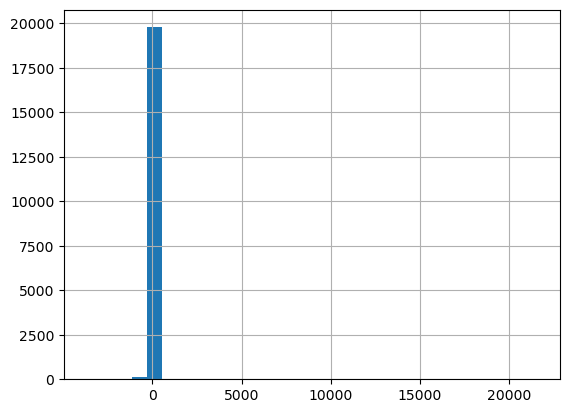

In [130]:
import scipy.stats as stats

# Rozkład różnic per SKU
straty_sku = df_rem_compare.groupby('SKU')['roznica'].sum()

# 1. Czy rozkład jest normalny?
stat, p = stats.shapiro(straty_sku)
print(f"Shapiro-Wilk: stat={stat:.3f}, p={p:.3f}")
print("Rozkład normalny" if p > 0.05 else "Rozkład NIE jest normalny")

# 2. Czy średnia strat różni się istotnie od 0?
t_stat, p_val = stats.ttest_1samp(straty_sku, popmean=0)
print(f"\nt-test: stat={t_stat:.3f}, p={p_val:.3f}")
print("Straty LOSOWE (brak systematycznego błędu)" if p_val > 0.05 
      else "Straty SYSTEMATYCZNE (nie są losowe)")

# 3. Histogram
straty_sku.hist(bins=30)

In [131]:
# Sprawdź co jest tym outlierem
print(straty_sku.sort_values().head(10))
print(straty_sku.sort_values().tail(10))
print(straty_sku.describe())

SKU
68      -3694.30
49811   -1731.26
36355   -1549.00
14248   -1491.00
7741    -1483.00
86      -1404.00
7430    -1404.00
2977    -1323.00
6300    -1314.00
7429    -1312.00
Name: roznica, dtype: float64
SKU
55353     752.00
77513     761.00
55393     764.00
17619     846.00
77531     873.00
55352     976.00
18654    1493.00
54316    2901.96
38960    3482.00
18674   21603.00
Name: roznica, dtype: float64
count   19920.00
mean       -7.70
std       171.57
min     -3694.30
25%        -1.00
50%         0.00
75%         0.00
max     21603.00
Name: roznica, dtype: float64


Usunięto 60 outlierów


<Axes: >

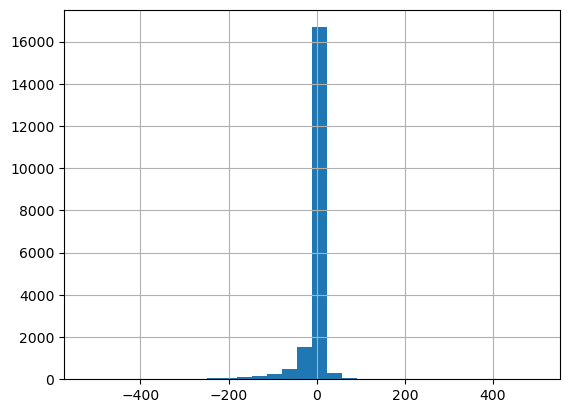

In [132]:
# Odetnij ekstrema np. poza 3 odchyleniami standardowymi
mean = straty_sku.mean()
std = straty_sku.std()

straty_bez_outlierow = straty_sku[
    (straty_sku > mean - 3*std) & 
    (straty_sku < mean + 3*std)
]

print(f"Usunięto {len(straty_sku) - len(straty_bez_outlierow)} outlierów")
straty_bez_outlierow.hist(bins=30)

In [133]:
# Czy te same SKU tracą przy każdym remanencie?
df_rem_compare.pivot_table(
    index='SKU', 
    columns='data_rem', 
    values='roznica'
).head(20)

data_rem,2023-01-02,2023-01-04,2023-01-05,2023-01-09,2023-02-09,2023-02-10,2023-02-19,2023-02-20,2023-02-21,2023-02-23,...,2025-11-17,2025-11-18,2025-11-21,2025-11-24,2025-11-27,2025-12-01,2025-12-08,2025-12-10,2025-12-11,2025-12-30
SKU,,,,,,,,,,,,,,,,,,,,,
5,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,NaN,NaN,NaN,NaN,NaN,NaN,-1.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,NaN,NaN,NaN,NaN,NaN,NaN,-1.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


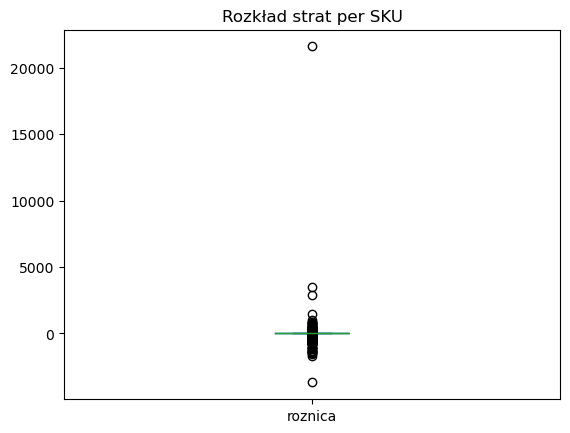

In [134]:
import matplotlib.pyplot as plt
straty_sku.plot.box()
plt.title('Rozkład strat per SKU')
plt.show()

SKU
18674   21603.00
38960    3482.00
54316    2901.96
18654    1493.00
55352     976.00
Name: roznica, dtype: float64
              Data  TypDok                  NrDok  IloscPlus  IloscMinus
2856341 2023-01-01      14                BO/23/1  -11346.00        0.00
2876565 2023-01-01      14                BO/23/2       0.00        0.00
2174    2023-01-02      21     DF/PAR/230102/38/1       0.00       10.00
4204    2023-01-02      21    DF/PAR/230102/469/2       0.00        1.00
4190    2023-01-02      21    DF/PAR/230102/466/2       1.00        0.00
...            ...     ...                    ...        ...         ...
3711188 2025-12-31      21  DF/PAR/251231/15860/2       1.00        0.00
3711172 2025-12-31      21  DF/PAR/251231/15858/2       1.00        0.00
3709657 2025-12-31       1            OPAK/D/25/1      20.00        0.00
3712764 2025-12-31      21  DF/PAR/251231/16086/2       2.00        0.00
3713709 2025-12-31      21  DF/PAR/251231/16273/2       1.00        0.00

[111

<Axes: >

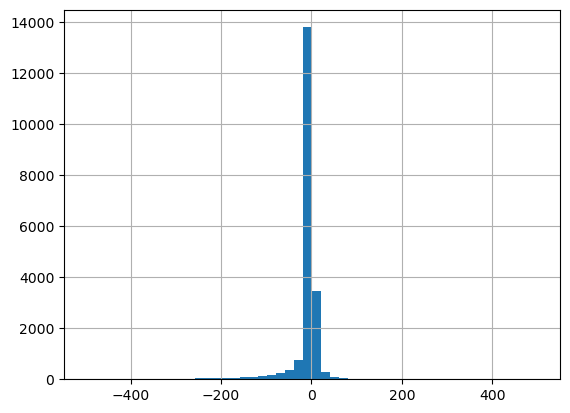

In [135]:
# 1. Znajdź ten outlier +22000
print(straty_sku.sort_values(ascending=False).head(5))

# 2. Sprawdź czy to błąd danych
sku_outlier = straty_sku.idxmax()
print(df[df['SKU'] == sku_outlier][
    ['Data', 'TypDok', 'NrDok', 'IloscPlus', 'IloscMinus']
].sort_values('Data'))

# 3. Histogram bez outlierów (zakres -500 do +500)
straty_sku[straty_sku.between(-500, 500)].hist(bins=50)

In [136]:
roznica_col = df_rem_compare['roznica']

print(f"Liczba SKU z różnicą = 0:     {(roznica_col == 0).sum()}")
print(f"Liczba SKU z niedoborem (<0):  {(roznica_col < 0).sum()}")
print(f"Liczba SKU z nadwyżką (>0):    {(roznica_col > 0).sum()}")
print()
print(f"Średnia strata:  {roznica_col[roznica_col < 0].mean():.1f}")
print(f"Mediana straty:  {roznica_col[roznica_col < 0].median():.1f}")
print(f"Łączny niedobór: {roznica_col[roznica_col < 0].sum():.0f} szt")
print(f"Łączna nadwyżka: {roznica_col[roznica_col > 0].sum():.0f} szt")

Liczba SKU z różnicą = 0:     32297
Liczba SKU z niedoborem (<0):  12794
Liczba SKU z nadwyżką (>0):    8897

Średnia strata:  -21.4
Mediana straty:  -7.0
Łączny niedobór: -273888 szt
Łączna nadwyżka: 120592 szt


In [137]:
# SKU które ZAWSZE mają niedobór
zawsze_niedobor = (
    df_rem_compare
    .groupby('SKU')
    .apply(lambda x: (x['roznica'] < 0).all())
)
print(f"SKU zawsze na minusie: {zawsze_niedobor.sum()}")

# SKU które ZAWSZE mają nadwyżkę  
zawsze_nadwyzka = (
    df_rem_compare
    .groupby('SKU')
    .apply(lambda x: (x['roznica'] > 0).all())
)
print(f"SKU zawsze na plusie: {zawsze_nadwyzka.sum()}")

SKU zawsze na minusie: 2150
SKU zawsze na plusie: 625


## które SKU generują 80% obrotu

In [138]:
# Sprzedaż per SKU (tylko TypDok 21 i 59)
sprzedaz_sku = (
    df[df['TypDok'].isin([21])]
    .groupby(['SKU', 'Nazwa_towar'])
    .agg(
        wolumen=('IloscPlus', 'sum'),
        wartosc=('Wartosc', 'sum')
    )
    .reset_index()
    .sort_values('wartosc', ascending=False)
)

# Udział skumulowany
sprzedaz_sku['udzial_proc'] = (
    sprzedaz_sku['wartosc'] / sprzedaz_sku['wartosc'].sum() * 100
)
sprzedaz_sku['udzial_kum'] = sprzedaz_sku['udzial_proc'].cumsum()

# Segment Pareto
sprzedaz_sku['pareto'] = sprzedaz_sku['udzial_kum'].apply(
    lambda x: 'A (top 80%)' if x <= 80 
    else 'B (80-95%)' if x <= 95 
    else 'C (ogon)'
)

print(sprzedaz_sku['pareto'].value_counts())
print()
print(f"Łączna wartość sprzedaży: {sprzedaz_sku['wartosc'].sum():,.0f}")
display(sprzedaz_sku.head(20))

pareto
C (ogon)       6969
B (80-95%)     3218
A (top 80%)    2812
Name: count, dtype: int64

Łączna wartość sprzedaży: 16,165,768


,SKU,Nazwa_towar,wolumen,wartosc,udzial_proc,udzial_kum,pareto
4480,49624,BANAN /KG,18375.94,110386.12,0.68,0.68,A (top 80%)
17,75,PIECZYWO MIX,28931.00,96731.55,0.60,1.28,A (top 80%)
821,4685,WÓDKA ŻUBRÓWKA BIAŁA 40% 500ML CEDC,3847.00,88316.69,0.55,1.83,A (top 80%)
2171,11978,WÓDKA ŻOŁĄDKOWA DE LUX 40% 500ML STOCK,3398.00,78308.14,0.48,2.31,A (top 80%)
2951,17470,SER PROMOCJA KG,2636.32,66562.93,0.41,2.72,A (top 80%)
2609,15149,PAPIEROSY WINSTON BLUE SUPER LINE JTI,4488.00,65286.75,0.40,3.13,A (top 80%)
34,96,BUŁKA KAJZERKA 50G MAREL,76979.00,61575.13,0.38,3.51,A (top 80%)
3362,23551,BILET 4.40,13119.00,53447.70,0.33,3.84,A (top 80%)
2608,15148,PAPIEROSY WINSTON GREEN SUPER LINE 20SZT JTI,3607.00,52650.84,0.33,4.16,A (top 80%)
2772,16491,SER ZŁOTY MAZUR MLEKPOL KG,1829.98,52323.34,0.32,4.49,A (top 80%)


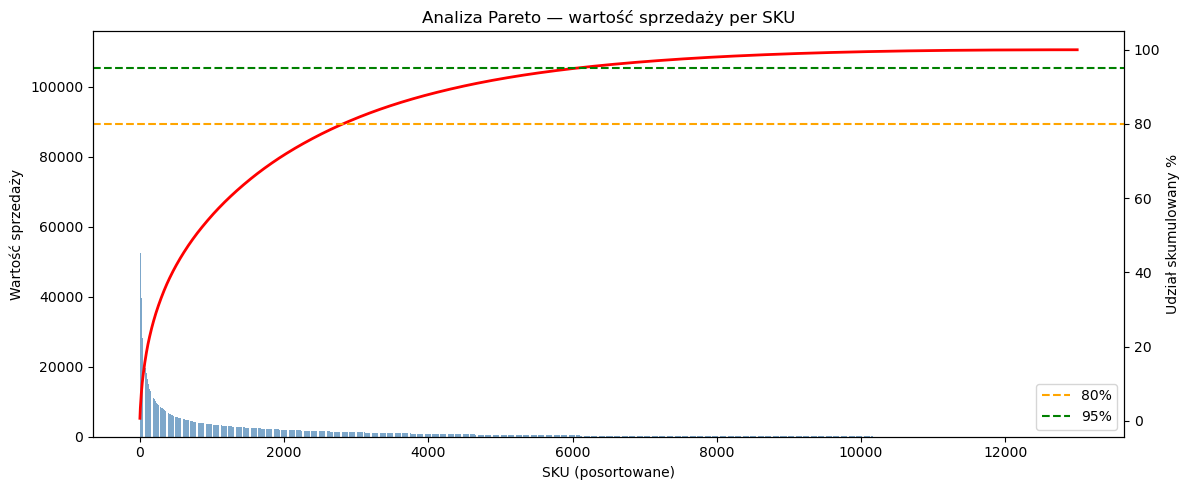

In [139]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 5))

# Słupki wartości
ax1.bar(range(len(sprzedaz_sku)), sprzedaz_sku['wartosc'], color='steelblue', alpha=0.7)
ax1.set_xlabel('SKU (posortowane)')
ax1.set_ylabel('Wartość sprzedaży')

# Linia kumulatywna
ax2 = ax1.twinx()
ax2.plot(range(len(sprzedaz_sku)), sprzedaz_sku['udzial_kum'], color='red', linewidth=2)
ax2.axhline(y=80, color='orange', linestyle='--', label='80%')
ax2.axhline(y=95, color='green', linestyle='--', label='95%')
ax2.set_ylabel('Udział skumulowany %')
ax2.legend()

plt.title('Analiza Pareto — wartość sprzedaży per SKU')
plt.tight_layout()
plt.show()

### Ile % SKU to segment A:

In [140]:
total_sku = len(sprzedaz_sku)
sku_A = (sprzedaz_sku['pareto'] == 'A (top 80%)').sum()
print(f"Segment A: {sku_A} SKU = {sku_A/total_sku*100:.1f}% wszystkich SKU generuje 80% obrotu")
print(f"Segment C: {6977} SKU = {6977/total_sku*100:.1f}% wszystkich SKU generuje tylko 5% obrotu")

Segment A: 2812 SKU = 21.6% wszystkich SKU generuje 80% obrotu
Segment C: 6977 SKU = 53.7% wszystkich SKU generuje tylko 5% obrotu


In [141]:
# Dodaj segment Pareto do głównego df
df = df.merge(
    sprzedaz_sku[['SKU', 'pareto']], 
    on='SKU', 
    how='left'
)
df['pareto'] = df['pareto'].fillna('D (brak sprzedaży)')
print(df['pareto'].value_counts())

pareto
A (top 80%)           2696577
B (80-95%)             680991
C (ogon)               255797
D (brak sprzedaży)      55921
Name: count, dtype: int64


In [142]:
# Czy produkty z ogona mają większe straty?
straty_pareto = (
    df_rem_compare
    .merge(sprzedaz_sku[['SKU', 'pareto']], on='SKU', how='left')
    .groupby('pareto')['roznica']
    .agg(['mean', 'sum', 'count'])
    .round(1)
)
print(straty_pareto)

              mean        sum  count
pareto                              
A (top 80%) -13.90 -135922.30   9750
B (80-95%)   -2.80  -23368.40   8439
C (ogon)      0.60    8080.00  12515


### Które produkty sprzedają się najlepiej


In [143]:
# Top 20 produktów po wartości sprzedaży
print("=== TOP 20 po wartości ===")
display(
    sprzedaz_sku[['Nazwa_towar', 'wartosc', 'wolumen', 'udzial_proc']].sort_values('wartosc', ascending=False)
    .head(20)
)

=== TOP 20 po wartości ===


,Nazwa_towar,wartosc,wolumen,udzial_proc
4480,BANAN /KG,110386.12,18375.94,0.68
17,PIECZYWO MIX,96731.55,28931.00,0.60
821,WÓDKA ŻUBRÓWKA BIAŁA 40% 500ML CEDC,88316.69,3847.00,0.55
2171,WÓDKA ŻOŁĄDKOWA DE LUX 40% 500ML STOCK,78308.14,3398.00,0.48
2951,SER PROMOCJA KG,66562.93,2636.32,0.41
2609,PAPIEROSY WINSTON BLUE SUPER LINE JTI,65286.75,4488.00,0.40
34,BUŁKA KAJZERKA 50G MAREL,61575.13,76979.00,0.38
3362,BILET 4.40,53447.70,13119.00,0.33
2608,PAPIEROSY WINSTON GREEN SUPER LINE 20SZT JTI,52650.84,3607.00,0.33
2772,SER ZŁOTY MAZUR MLEKPOL KG,52323.34,1829.98,0.32


In [144]:
# Top 20 po wolumenie (ilości sztuk)
print("=== TOP 20 po wolumenie (sztuki) ===")
display(
    sprzedaz_sku[['Nazwa_towar', 'wolumen', 'wartosc']]
    .sort_values('wartosc', ascending=False)
    .head(20)
)

=== TOP 20 po wolumenie (sztuki) ===


,Nazwa_towar,wolumen,wartosc
4480,BANAN /KG,18375.94,110386.12
17,PIECZYWO MIX,28931.00,96731.55
821,WÓDKA ŻUBRÓWKA BIAŁA 40% 500ML CEDC,3847.00,88316.69
2171,WÓDKA ŻOŁĄDKOWA DE LUX 40% 500ML STOCK,3398.00,78308.14
2951,SER PROMOCJA KG,2636.32,66562.93
2609,PAPIEROSY WINSTON BLUE SUPER LINE JTI,4488.00,65286.75
34,BUŁKA KAJZERKA 50G MAREL,76979.00,61575.13
3362,BILET 4.40,13119.00,53447.70
2608,PAPIEROSY WINSTON GREEN SUPER LINE 20SZT JTI,3607.00,52650.84
2772,SER ZŁOTY MAZUR MLEKPOL KG,1829.98,52323.34


## Ilosc ZAM i PZ

In [145]:
print("=== ZAM (TypDok=50) ===")
print(df[df['TypDok']==50].groupby('Nazwa_towar')['IloscPlus'].agg(['sum','count']).sort_values('sum', ascending=False).head(20))


=== ZAM (TypDok=50) ===
                                                   sum  count
Nazwa_towar                                                  
BILET 4.40                                    15010.00    152
WODA MIN N/GAZ MUSZYNIANKA 1,5L MUSZYNIANKA   12849.00    266
ŚMIETANA KUB 18% 200G PIĄTNICA                10860.00    382
BILET 2,2                                      9510.00     97
SEREK WIEJSKI LEKKI 150G PIĄTNICA              9192.00    389
SEREK WIEJSKI NATURALNY 200G PIĄTNICA          8784.00    392
MASŁO EKSTR A 83% 200G SPAR                    8280.00    172
SEREK WIEJSKI ZE SZCZYPIORKIEM 200G ŁÓDŹ       7380.00    154
LODY BAMBINO W CZEKOLADZIE ŁÓDŹ                7301.00    126
MLEKO ŚWIEŻE BUT ŁACIATE 3,2% 1L MLEKPOL       7010.00    398
MLEKO ŚWIEŻE BUT ŁACIATE 2% 1L MLEKPOL         6672.00    389
WODA GAZ ŻYWIEC ZDRÓJ 1,5L                     6535.00    247
JOGURT PRIMO NATURALNY B/L 180G ZOTT           6368.00    304
JOGURT NATURALNY PRIMO 180G ZOTT              

In [146]:

print("\n=== PZ (TypDok=2) ===")
print(df[df['TypDok']==2].groupby('Nazwa_towar')['IloscPlus'].agg(['sum','count']).sort_values('sum', ascending=False).head(20))



=== PZ (TypDok=2) ===
                                                 sum  count
Nazwa_towar                                                
BUŁKA KAJZERKA 50G MAREL                    77766.00    169
TORBA RECYKLING SPAR 30X55 1SZT             43500.00     70
Bulka poznanska 0.1                         38059.00    163
PIECZYWO MIX                                29666.00   2053
BUŁKA KAJZERKA PRECELEK                     21064.00    165
BANAN /KG                                   19707.00    422
BUŁKA ZIARNO MIX                            18071.00   1076
Rogal maslany nowy POLPAIN                  16644.00    308
Chleb mieszany krojony 0.6kg    PRECELEK    13895.00    337
BILET 4.40                                  13400.00    134
WODA MIN N/GAZ MUSZYNIANKA 1,5L MUSZYNIANKA 13386.00    274
ŚMIETANA KUB 18% 200G PIĄTNICA              10748.00    375
PĄCZEK SZT                                   9759.00     71
SEREK WIEJSKI LEKKI 150G PIĄTNICA            9231.00    392
BILET 2,2        

In [147]:

print("\n=== Podsumowanie ===")
print(f"Liczba ZAM: {(df['TypDok']==50).sum()}")
print(f"Liczba PZ:  {(df['TypDok']==2).sum()}")
print(f"Suma ZAM:   {df[df['TypDok']==50]['IloscPlus'].sum():.0f} szt")
print(f"Suma PZ:    {df[df['TypDok']==2]['IloscPlus'].sum():.0f} szt")


=== Podsumowanie ===
Liczba ZAM: 205539
Liczba PZ:  254535
Suma ZAM:   2558010 szt
Suma PZ:    3696228 szt


## Na czym się najwięcęj zarabia

In [148]:
print("=== TOP 20 po marży łącznej ===")
display(
    df[df['TypDok'].isin([21])]
    .groupby('Nazwa_towar')['Marza']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)


=== TOP 20 po marży łącznej ===


Nazwa_towar
TORBA RECYKLING SPAR 30X55 1SZT               8603.60
BANAN /KG                                     5661.00
BUŁKA KAJZERKA 50G MAREL                      4777.00
PIECZYWO MIX                                  3895.60
CYTRYNY TURCJA KG                             3121.65
Bulka poznanska 0.1                           2960.40
Chleb mieszany krojony 0.6kg    PRECELEK      2330.80
Rogal maslany nowy POLPAIN                    2219.80
SER PROMOCJA KG                               2076.40
BUŁKA ZIARNO MIX                              2053.20
ŚMIETANA KUB 18% 200G PIĄTNICA                1976.00
JABŁKA POLSKA KG                              1944.40
CHLEB MIESZANY KROJONY 500G MAREL             1887.00
MANDARYNKA 1KG LUZ HISZPANIA                  1708.60
CHALKA 0,5KG PRECELEK                         1568.80
CEBULA W ŁUSCE POLSKA KG                      1562.20
MLEKO ŚWIEŻE BUT ŁACIATE 3,2% 1L MLEKPOL      1560.00
OGÓREK WĘŻOWY POLSKA KG                       1484.60
CHLEB MIESZANY K

In [149]:


print("=== TOP 20 po % marży ===")
marza_proc = (
    df[df['TypDok'].isin([21])]
    .groupby('Nazwa_towar')
    .agg(
        marza=('Marza', 'sum'),
        wartosc=('Wartosc', 'sum')
    )
)
marza_proc['marza_proc'] = (marza_proc['marza'] / marza_proc['wartosc'] * 100).round(1)
display(marza_proc.sort_values('marza_proc', ascending=False).head(20))

=== TOP 20 po % marży ===


,marza,wartosc,marza_proc
Nazwa_towar,,,
Reklamówka biodegradowalna,98.00,42.90,228.50
KUBEK JEDNORAZOWY,0.40,0.49,82.00
GUMA CENTER SHOCK MONSTER 4G VAN MELE,18.50,45.88,40.30
Czapeczki 1 szt,0.30,0.80,37.30
TORBA RECYKLING SPAR 30X55 1SZT,8603.60,24567.24,35.00
REKLAMÓWKA SPAR średnia,23.20,70.00,33.10
"REKLAMÓWKA MIKOŁAJ, CHOINKA",35.80,110.41,32.40
WYKAŁACZKI ZAPAS 100SZT PIKNIK,3.90,12.58,31.00
GUMA CENTER SHOCK JABŁKO 4G VAN MELE,17.25,57.73,29.90


In [150]:
df['marza_zl'] = df['Wartosc'] * df['Marza'] / 100

In [151]:
df.head(10)

,DokId,SKU,IloscPlus,IloscMinus,CenaPoRab,Wartosc,Data,NrDok,TypDok,AsId,...,DzienTygodnia,czy_remanent,ilosc_netto,Ruch,nazwa_dnia,dlugi_weekend,niedziela_handlowa,kategoria_dnia,pareto,marza_zl
0,1165932,24787,1.00,0.00,4.86,4.86,2023-01-02,D20230102/50189/CDPRS/23/287,81,133.00,...,0,False,NaN,NaN,Poniedziałek,False,False,Poniedziałek,C (ogon),0.00
1,1165932,18670,2.00,0.00,2.96,5.92,2023-01-02,D20230102/50189/CDPRS/23/287,81,132.00,...,0,False,NaN,NaN,Poniedziałek,False,False,Poniedziałek,C (ogon),0.00
2,1165932,18653,7.00,0.00,2.25,15.75,2023-01-02,D20230102/50189/CDPRS/23/287,81,132.00,...,0,False,NaN,NaN,Poniedziałek,False,False,Poniedziałek,A (top 80%),0.00
3,1165932,18668,9.00,0.00,2.10,18.90,2023-01-02,D20230102/50189/CDPRS/23/287,81,132.00,...,0,False,NaN,NaN,Poniedziałek,False,False,Poniedziałek,A (top 80%),0.00
4,1165932,22303,2.00,0.00,5.62,11.24,2023-01-02,D20230102/50189/CDPRS/23/287,81,273.00,...,0,False,NaN,NaN,Poniedziałek,False,False,Poniedziałek,C (ogon),0.00
5,1165932,36367,1.00,0.00,2.46,2.46,2023-01-02,D20230102/50189/CDPRS/23/287,81,133.00,...,0,False,NaN,NaN,Poniedziałek,False,False,Poniedziałek,C (ogon),0.00
6,1165932,20801,2.00,0.00,2.74,5.48,2023-01-02,D20230102/50189/CDPRS/23/287,81,132.00,...,0,False,NaN,NaN,Poniedziałek,False,False,Poniedziałek,B (80-95%),0.00
7,1165932,20958,2.00,0.00,3.17,6.34,2023-01-02,D20230102/50189/CDPRS/23/287,81,132.00,...,0,False,NaN,NaN,Poniedziałek,False,False,Poniedziałek,C (ogon),0.00
8,1165932,18656,2.00,0.00,4.92,9.84,2023-01-02,D20230102/50189/CDPRS/23/287,81,132.00,...,0,False,NaN,NaN,Poniedziałek,False,False,Poniedziałek,B (80-95%),0.00
9,1165932,55322,10.00,0.00,4.93,49.30,2023-01-02,D20230102/50189/CDPRS/23/287,81,132.00,...,0,False,NaN,NaN,Poniedziałek,False,False,Poniedziałek,A (top 80%),0.00


In [152]:
# artykuly 2023
df_2023_1 = df[
    (df['Rok'] == 2023) & 
    (df['Miesiac'] == 1)
].copy()
df_2023_1.to_csv('dane_all_product/artykuly_2023_1.csv',index=False)
# artykuly 2024
# df_2024 = df[df['Rok'] == 2024].copy()
# df_2024.to_csv('dane_all_product/artykuly_2024.csv',index=False)
# #artykuly 2025
# df_2025 = df[df['Rok'] == 2025].copy()
# df_2025.to_csv('dane_all_product/artykuly_2025.csv',index=False)

OSError: Cannot save file into a non-existent directory: 'dane_all_product'

In [ ]:
df.sample(5)

,DokId,SKU,IloscPlus,IloscMinus,CenaPoRab,Wartosc,Data,NrDok,TypDok,AsId,...,DzienTygodnia,czy_remanent,ilosc_netto,Ruch,nazwa_dnia,dlugi_weekend,niedziela_handlowa,kategoria_dnia,pareto,marza_zl
3109104,2045581,50009,1.00,0.00,2.09,2.09,2025-06-27,DF/PAR/250627/8852/1,21,115.00,...,4,False,-0.00,-0.00,Piątek,False,False,Piątek,A (top 80%),0.00
104144,1202880,20348,1.00,0.00,7.40,7.40,2023-02-03,DF/PAR/230203/560/1,21,132.00,...,4,False,-0.00,-0.00,Piątek,False,False,Piątek,A (top 80%),0.00
49166,1178799,1002,1.00,0.00,2.79,2.79,2023-01-17,DF/PAR/230117/4300/1,21,86.00,...,1,False,-0.00,-0.00,Wtorek,False,False,Wtorek,A (top 80%),0.00
3362368,2124652,52417,1.00,0.00,5.70,5.70,2025-09-18,DF/PAR/250918/4170/1,21,217.00,...,3,False,-0.00,-0.00,Czwartek,False,False,Czwartek,A (top 80%),0.01
3366090,2125645,36585,1.00,0.00,4.09,4.09,2025-09-19,DF/PAR/250919/9486/2,21,94.00,...,4,False,-0.00,-0.00,Piątek,False,False,Piątek,A (top 80%),0.01


In [ ]:
df.columns

Index(['DokId', 'SKU', 'IloscPlus', 'IloscMinus', 'CenaPoRab', 'Wartosc',
       'Data', 'NrDok', 'TypDok', 'AsId', 'Nazwa_towar', 'Kod', 'Marza',
       'CenaDet', 'Nazwa_asort', 'Rok', 'Miesiac', 'RokMiesiac',
       'DzienTygodnia', 'czy_remanent', 'ilosc_netto', 'Ruch', 'nazwa_dnia',
       'dlugi_weekend', 'niedziela_handlowa', 'kategoria_dnia', 'pareto',
       'marza_zl'],
      dtype='object')

## Co najlepiej sprzedaje się w piątki

In [ ]:
for i in range(1, 13):
    df_month = df[df['Miesiac'] == i].copy()
    piatki = df_month[(df_month['nazwa_dnia'] == 'Piątek')]
    top = piatki.groupby(['SKU', 'Nazwa_towar']).agg(
    wartosc=('Wartosc', 'sum'),
    ilosc=('ilosc_netto', 'sum')
).sort_values('wartosc', ascending=False)
    print(f"\n=== Miesiąc {i} - TOP Piątki ===")
    display(top.head(5))


=== Miesiąc 1 - TOP Piątki ===


,,wartosc,ilosc
SKU,Nazwa_towar,,
14957,CUKIER KRYSZTAŁ SWEET FAMILY 1KG NORDZUCKER,7170.63,450.00
49624,BANAN /KG,5570.46,646.21
11978,WÓDKA ŻOŁĄDKOWA DE LUX 40% 500ML STOCK,4282.49,150.00
17470,SER PROMOCJA KG,3982.38,71.52
4685,WÓDKA ŻUBRÓWKA BIAŁA 40% 500ML CEDC,3729.57,105.00



=== Miesiąc 2 - TOP Piątki ===


,,wartosc,ilosc
SKU,Nazwa_towar,,
50008,MANDARYNKA 1KG LUZ HISZPANIA,5362.02,611.87
49624,BANAN /KG,5262.15,666.58
4685,WÓDKA ŻUBRÓWKA BIAŁA 40% 500ML CEDC,4080.69,105.00
15149,PAPIEROSY WINSTON BLUE SUPER LINE JTI,3958.38,160.00
17470,SER PROMOCJA KG,3907.93,101.88



=== Miesiąc 3 - TOP Piątki ===


...

,,wartosc,ilosc
SKU,Nazwa_towar,,
15148,PAPIEROSY WINSTON GREEN SUPER LINE 20SZT JTI,5017.91,180.00
4685,WÓDKA ŻUBRÓWKA BIAŁA 40% 500ML CEDC,4777.55,150.00
15149,PAPIEROSY WINSTON BLUE SUPER LINE JTI,4750.52,160.00
66340,PAPIEROSY L&M FIRST CUT ZIELONE SSL PM,4469.75,150.00
23551,BILET 4.40,4244.40,600.00



=== Miesiąc 11 - TOP Piątki ===


,,wartosc,ilosc
SKU,Nazwa_towar,,
4685,WÓDKA ŻUBRÓWKA BIAŁA 40% 500ML CEDC,5176.13,210.00
49624,BANAN /KG,4600.83,513.16
17470,SER PROMOCJA KG,4514.65,64.17
15148,PAPIEROSY WINSTON GREEN SUPER LINE 20SZT JTI,3986.17,200.00
15149,PAPIEROSY WINSTON BLUE SUPER LINE JTI,3874.12,200.00



=== Miesiąc 12 - TOP Piątki ===


,,wartosc,ilosc
SKU,Nazwa_towar,,
49624,BANAN /KG,5000.98,735.72
4685,WÓDKA ŻUBRÓWKA BIAŁA 40% 500ML CEDC,4206.46,150.00
17470,SER PROMOCJA KG,3890.81,86.63
12108,"WÓDKA ŻUBR STRONG 37,5% 90ML STOCK",3789.34,448.00
55191,MASŁO EKSTR A 83% 200G SPAR,3128.37,350.00


In [ ]:
for i in range(1, 13):
    df_month = df[df['Miesiac'] == i].copy()
    dlugi_weekend = df_month[(df_month['dlugi_weekend'] == True)]
    top = dlugi_weekend.groupby(['SKU', 'Nazwa_towar']).agg(
    wartosc=('Wartosc', 'sum'),
    ilosc=('ilosc_netto', 'sum')
).sort_values('wartosc', ascending=False)
    print(f"\n=== Miesiąc {i} - TOP Długi Weekend ===")
    display(top.head(5))


=== Miesiąc 1 - TOP Długi Weekend ===


,,wartosc,ilosc
SKU,Nazwa_towar,,



=== Miesiąc 2 - TOP Długi Weekend ===


,,wartosc,ilosc
SKU,Nazwa_towar,,



=== Miesiąc 3 - TOP Długi Weekend ===


...

,,wartosc,ilosc
SKU,Nazwa_towar,,
17619,SZYSZKA FIGARO Z LIKIEREM ADVOCAT/CZEKOLADA 27G IDC,1242.00,900.00
75,PIECZYWO MIX,1002.40,276.00
49624,BANAN /KG,948.90,36.00
14366,PAPIEROSY PALL MALL LONGS BLUE SSL 20SZT B.A.T.,944.66,30.00
38543,"WÓDKA STUMBRAS PIGWA 0,1L STUMBRAS",900.35,48.00



=== Miesiąc 11 - TOP Długi Weekend ===


,,wartosc,ilosc
SKU,Nazwa_towar,,
18674,"Butelka zwrotna 0,5",1911.00,1878.00
16584,KAWA ROZP SŁOIK NESCAFE CREME SENSAZIONE 200G NESTLE,1030.85,17.00
16491,SER ZŁOTY MAZUR MLEKPOL KG,943.24,18.70
54316,PRZECENA WARZYWA OWOCE,898.10,111.10
50008,MANDARYNKA 1KG LUZ HISZPANIA,756.72,45.24



=== Miesiąc 12 - TOP Długi Weekend ===


,,wartosc,ilosc
SKU,Nazwa_towar,,


### Sprawdzam jak się sprzedają kategorie asortyment

In [ ]:
len(list(df.AsId.unique()))

298

In [ ]:
# Agregacja per kategoria
agg = df.groupby(['AsId', 'Nazwa_asort']).agg(
    wartosc=('Wartosc', 'sum'),
    
    ilosc_sku=('SKU', 'nunique'),
    transakcje=('DokId', 'nunique')   
).reset_index()


In [ ]:
agg['wartosc_na_sku'] = (agg['wartosc'] / agg['ilosc_sku']).round(0)

In [ ]:
# Klasyfikacja wg wartość
def klasyfikuj(val):
    if val == 0:   return 'ZERO - brak sprzedaży'
    if val < 0:    return 'UJEMNE - zwroty'
    if val < 500:  return 'MARGINALNE'
    return 'AKTYWNA'

In [ ]:
agg['status'] = agg['wartosc'].apply(klasyfikuj)

In [ ]:
# Podgląd kandydatów do usunięcia
zbedne = agg[agg['status'].isin(['ZERO - brak sprzedaży', 'MARGINALNE'])]
print(f"Kandydaci do usunięcia: {len(zbedne)} kategorii")
display(zbedne[['AsId', 'Nazwa_asort', 'wartosc', 'ilosc_sku', 'status']])


Kandydaci do usunięcia: 58 kategorii


,AsId,Nazwa_asort,wartosc,ilosc_sku,status
31,33.00,DODATKI SPOŻYWCZE,0.00,1,ZERO - brak sprzedaży
44,47.00,x DOŁADOWANIA,0.00,14,ZERO - brak sprzedaży
45,48.00,DOŁADOWANIA I STARTERY,0.00,2,ZERO - brak sprzedaży
48,51.00,PARAFARMACEUTYKI /farmaceutyki,20.93,2,MARGINALNE
50,53.00,ŚRODKI OPATRUNKOWE /farmaceutyki,216.50,15,MARGINALNE
51,54.00,x KOSMETYKI,405.87,30,MARGINALNE
53,56.00,BIO /kosmetyki,0.00,22,ZERO - brak sprzedaży
61,65.00,ZESTAWY I KOSMETYCZKI /kosmetyki,416.83,2,MARGINALNE
101,107.00,OWOCE I WARZYWA,0.00,2,ZERO - brak sprzedaży
120,126.00,"PIZZE, ZAPIEKANKI I CEBULAKI",114.69,4,MARGINALNE


In [ ]:
# # Progi ilości transakcji
print(sku['transakcje'].describe())
print()
print(sku['transakcje'].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

count   21864.00
mean      166.88
std       647.80
min         1.00
25%         5.00
50%        14.00
75%       108.00
max     43096.00
Name: transakcje, dtype: float64

0.10      5.00
0.25      5.00
0.50     14.00
0.75    108.00
0.90    438.70
0.95    771.00
0.99   2008.11
Name: transakcje, dtype: float64


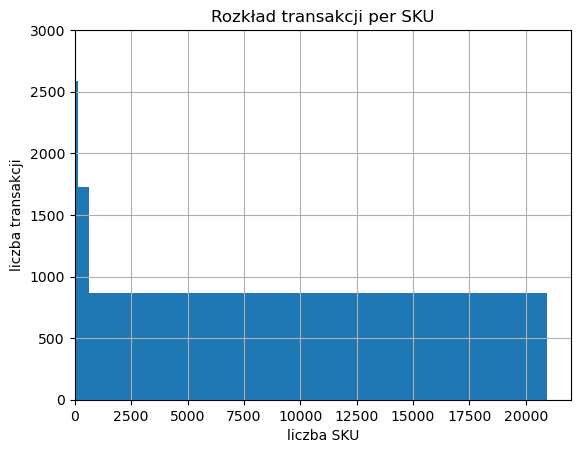

In [ ]:
sku['transakcje'].hist(bins=50, orientation='horizontal')
plt.ylabel('liczba transakcji')
plt.xlabel('liczba SKU')
plt.ylim(0, 3000)
plt.title('Rozkład transakcji per SKU')
plt.show()

In [ ]:
## Ilość transakcji na SKU
prog = 500
def klasyfikuj_tx(val):
    if val <100:    return 'D - brak'
    if (val >=100 and val < prog):    return 'C - sporadyczny'
    if (val>=prog and val<=1000):     return 'B - regularny'
    return 'A - popularny'

sku = df.groupby(['SKU', 'Nazwa_towar']).agg(
    transakcje=('DokId', 'nunique'),
    wartosc=('Wartosc', 'sum'),
    ilosc=('ilosc_netto', 'sum')
).reset_index()

sku['klasa_tx'] = sku['transakcje'].apply(klasyfikuj_tx)

print(sku['klasa_tx'].value_counts())

klasa_tx
D - brak           16188
C - sporadyczny     3769
B - regularny       1196
A - popularny        711
Name: count, dtype: int64


In [ ]:
# Klasyfikacja per kategoria AsId
prog = 500

def klasyfikuj_tx(val):
    if val < 100:                    return 'D - brak'
    if val >= 100 and val < prog:    return 'C - sporadyczny'
    if val >= prog:                  return 'B - regularny'
    return 'A - popularny'

asid = df.groupby(['AsId', 'Nazwa_asort']).agg(
    transakcje=('DokId', 'nunique'),
    wartosc=('Wartosc', 'sum'),
    ilosc_sku=('SKU', 'nunique')
).reset_index()

asid['klasa_tx'] = asid['transakcje'].apply(klasyfikuj_tx)

print(asid['klasa_tx'].value_counts())
print()
print(asid.sort_values('transakcje', ascending=True).to_string())

klasa_tx
B - regularny      191
D - brak            68
C - sporadyczny     39
Name: count, dtype: int64

      AsId                               Nazwa_asort  transakcje    wartosc  ilosc_sku         klasa_tx
281 338.00                                    VIRGIN           2      16.26          1         D - brak
278 334.00                                     HEYAH           4      99.93          5         D - brak
168 180.00                         INNE /przemysłowe           5       0.00          3         D - brak
45   48.00                    DOŁADOWANIA I STARTERY           5       0.00          2         D - brak
44   47.00                             x DOŁADOWANIA           5       0.00         14         D - brak
53   56.00                            BIO /kosmetyki           5       0.00         22         D - brak
159 170.00                    AGD I RTV /przemysłowe           5       0.00          2         D - brak
229 248.00                SMAKOSZ /dodatki spożywcze           

In [ ]:
for klasa in ['D - brak', 'C - sporadyczny', 'B - regularny']:
    print(f"\n=== {klasa} ===")
    print(asid[asid['klasa_tx'] == klasa][['AsId', 'Nazwa_asort', 'transakcje', 'wartosc']].to_string())


=== D - brak ===
      AsId                               Nazwa_asort  transakcje  wartosc
31   33.00                         DODATKI SPOŻYWCZE           8     0.00
44   47.00                             x DOŁADOWANIA           5     0.00
45   48.00                    DOŁADOWANIA I STARTERY           5     0.00
47   50.00                        LEKI /farmaceutyki          54   854.55
48   51.00            PARAFARMACEUTYKI /farmaceutyki           5    20.93
49   52.00                PREZERWATYWY /farmaceutyki           5    -1.04
50   53.00          ŚRODKI OPATRUNKOWE /farmaceutyki          28   216.50
51   54.00                               x KOSMETYKI           7   405.87
53   56.00                            BIO /kosmetyki           5     0.00
60   64.00                      DZIECIĘCE /kosmetyki          31   522.79
61   65.00          ZESTAWY I KOSMETYCZKI /kosmetyki           8   416.83
63   67.00                                GARMAŻERKA          47   532.05
64   68.00          